#### <FONT size="10pt"> <center>Notebook 02 - Modélisation</center></FONT>


## **Projet Rakuten - Classification multimodale de produits e-commerce**

### Objectif de ce notebook

Ce notebook couvre l'intégralité de la phase de modélisation. L'objectif est de prédire automatiquement la catégorie d'un produit (parmi 27 classes) à partir de son texte (désignation + description) et de son image.

Nous progressons du modèle le plus simple au plus complexe, en quatre étapes :

1. **Baseline TF-IDF + LinearSVC** : modèle de référence texte, rapide, CPU uniquement
2. **Embeddings multilingues SBERT + MLP** : représentation dense du texte, GPU optionnel
3. **Transfer Learning image ResNet50** : classification par l'image seule, GPU obligatoire
4. **Fusion multimodale** : combinaison texte + image pour exploiter les deux sources d'information

**Métrique principale :** weighted F1-score (imposée par le challenge Rakuten officiel)  
**Benchmarks de référence :** texte F1 = 0.8113 / image F1 = 0.5534 (Rakuten officiel)

> **Lexique rapide pour la lecture du notebook**  
> - **F1-score pondéré (weighted)** : moyenne du F1 par classe, pondérée par le nombre d'exemples de chaque classe. Adapté aux datasets déséquilibrés.  
> - **Epoch** : passage complet sur l'ensemble du dataset d'entraînement.  
> - **Loss** : erreur mesurée pendant l'entraînement. Plus elle baisse, mieux le modèle apprend.  
> - **Backbone** : partie centrale d'un réseau de neurones pré-entraîné, qui extrait les représentations visuelles.  
> - **Fine-tuning** : réentraînement partiel d'un modèle pré-entraîné pour l'adapter à une nouvelle tâche.  
> - **Embedding** : représentation vectorielle dense d'un texte ou d'une image dans un espace mathématique.

## 1 - Configuration et chargement

Cette cellule charge l'ensemble des bibliothèques nécessaires au notebook :
- **numpy / pandas / matplotlib / seaborn** : manipulation des données et visualisation.
- **scikit-learn** : pipeline TF-IDF, LinearSVC, LogisticRegression, métriques (F1, matrice de confusion), preprocessing.
- **PyTorch** (`torch`, `torchvision`) : framework deep learning PyTorch, modèles de vision, entraînement des réseaux de neurones (MLP, ResNet50).
- **sentence-transformers** : extraction d'embeddings multilingues denses.
- **tqdm** : barres de progression pour les boucles longues
- **joblib** : sérialisation des modèles sklearn.

Les graines aléatoires sont fixées (`RANDOM_STATE = 42`) pour garantir la **reproductibilité** de tous les splits et initialisations.

In [1]:
import os
import sys
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# Sentence-transformers
from sentence_transformers import SentenceTransformer

# Utilitaires
from tqdm.notebook import tqdm
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("Imports OK")

Imports OK


### 1.2 - Définition des chemins

Cette cellule recherche la racine du projet à partir du répertoire courant. Elle fonctionne lorsque Jupyter est lancé depuis la racine du projet ou depuis le dossier `notebooks`. Elle crée automatiquement les dossiers `models/`, `reports/figures/`
et `models/artifacts/` s'ils n'existent pas encore.

Les chemins définis sont :
- `DATA_PROC_DIR` : dossier contenant le dataset préprocessé exporté par le notebook 01.
- `IMAGE_TRAIN_DIR` : dossier contenant les 84 916 images produit.
- `MODELS_DIR` : dossier de sauvegarde des modèles entraînés.
- `ARTIFACTS_DIR` : dossier pour les fichiers intermédiaires (caches embeddings, features image).

In [2]:
# Recherche robuste de la racine depuis le projet ou le dossier notebooks
START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [START_DIR, *START_DIR.parents]
     if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Impossible de localiser la racine contenant data et notebooks."
    )

# Chemins
DATA_PROC_DIR   = PROJECT_ROOT / "data" / "processed"
IMAGE_TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "image_train"
MODELS_DIR      = PROJECT_ROOT / "models"
FIGURES_DIR     = PROJECT_ROOT / "reports" / "figures"
ARTIFACTS_DIR   = PROJECT_ROOT / "models" / "artifacts"

# Création des dossiers s'ils n'existent pas encore
for d in [MODELS_DIR, FIGURES_DIR, ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"MODELS_DIR   : {MODELS_DIR}")
print(f"FIGURES_DIR  : {FIGURES_DIR}")

PROJECT_ROOT : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl
MODELS_DIR   : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\models
FIGURES_DIR  : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\reports\figures


### 1.3 - Détection du dispositif de calcul (CPU ou GPU)

**Pourquoi cette étape est critique pour ce projet ?**

Les modèles de deep learning (ResNet50 pour les images, MLP sur embeddings) nécessitent des milliers d'opérations matricielles répétées. Un GPU (processeur graphique) peut effectuer ces opérations en parallèle sur des milliers de cœurs, ce qui le rend 10 à 100 fois plus rapide qu'un CPU pour ces tâches.

**Contexte matériel de ce projet :**  
La machine utilisée est équipée d'un GPU NVIDIA GeForce RTX 5070 Ti (architecture Blackwell, génération 2025), avec 12,8 Go de mémoire vidéo (VRAM). Cette carte appartient à la toute dernière génération NVIDIA, dont l'architecture (sm_120) n'était pas encore supportée par les versions stables de PyTorch au moment du projet. Il a donc fallu installer une version nightly (développement) de PyTorch compilée pour CUDA 12.8, via la commande :

```
pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128
```

Sans cette étape, PyTorch ne reconnaissait pas le GPU et tous les calculs se seraient déroulés sur le CPU, rendant l'entraînement des sections 3, 4 et 5 extrêmement lent (plusieurs heures supplémentaires).

**Ce que fait le code ci-dessous :**  
`torch.device("cuda" if torch.cuda.is_available() else "cpu")` détecte automatiquement si un GPU compatible CUDA est disponible. Si oui, `DEVICE = cuda` et tous les tenseurs et modèles seront envoyés sur le GPU. Sinon, le code bascule sur le CPU.


In [3]:
# Device GPU / CPU 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")
else:
    print("GPU non disponible - les étapes 3 et 4 nécessitent CUDA.")
    print("Les étapes 1 et 2 (baseline TF-IDF et embeddings texte) fonctionnent en CPU.")

Device utilisé : cuda
GPU : NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM disponible : 12.8 Go


**Résultat :** Le GPU est bien détecté et utilisé. Les entraînements s'exécuteront sur le GPU, réduisant drastiquement les temps de calcul.

### 1.4 - Chargement du dataset préparé

Cette cellule charge le fichier `df_train_processed.csv` produit par le notebook 01.
Ce fichier contient les données nettoyées et enrichies : les colonnes `designation_clean`,
`description_clean`, `text_combined` (concaténation des deux), ainsi que les chemins image.

Les NaN résiduels sur `text_combined` sont traités en deux passes :
1. Remplacement par `designation_clean` si disponible.
2. Remplacement par chaîne vide sinon.

Cette double sécurité garantit qu'aucune valeur nulle n'atteint les pipelines de modélisation.

In [4]:
# Chargement du dataset exporté par le notebook 01
processed_file = DATA_PROC_DIR / "df_train_processed.csv"
if not processed_file.is_file():
    raise FileNotFoundError(f"Fichier processed introuvable : {processed_file}")

df = pd.read_csv(processed_file, low_memory=False)
required_columns = {
    "designation_clean", "description_clean", "text_combined",
    "image_path", "productid", "imageid", "prdtypecode"
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"Colonnes obligatoires absentes : {missing_columns}")

# Remplacement des NaN résiduels sur text_combined
# (précaution : certaines lignes avec description vide peuvent produire des NaN à la concaténation)
df["text_combined"] = df["text_combined"].fillna(df["designation_clean"])
df["text_combined"] = df["text_combined"].fillna("").astype(str)
empty_text_mask = df["text_combined"].str.strip().eq("")
df.loc[empty_text_mask, "text_combined"] = (
    df.loc[empty_text_mask, "designation_clean"].fillna("").astype(str)
)

if df[["imageid", "productid", "prdtypecode"]].isna().any().any():
    raise ValueError("Des identifiants ou labels sont manquants dans le fichier processed.")
empty_text_count = int(df["text_combined"].str.strip().eq("").sum())
if empty_text_count == len(df):
    raise ValueError("La colonne text_combined ne contient aucun texte exploitable.")

sample_image_paths = df["image_path"].head(10).apply(Path)
sample_images_ok = sample_image_paths.apply(Path.is_file)
if not sample_images_ok.all():
    raise FileNotFoundError(
        "Au moins un chemin image de l'échantillon est invalide. Vérifier l'export du notebook 01."
    )

print(f"Fichier chargé : {processed_file}")
print(f"Dataset chargé : {df.shape}")
print(f"Classes : {df['prdtypecode'].nunique()}")
print(f"Valeurs manquantes text_combined : {df['text_combined'].isna().sum()}")
print(f"Textes vides après préparation : {empty_text_count}")
print(f"Images trouvées dans l'échantillon : {sample_images_ok.sum()} / {len(sample_images_ok)}")
df.head(3)

Fichier chargé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\processed\df_train_processed.csv
Dataset chargé : (84916, 29)
Classes : 27
Valeurs manquantes text_combined : 0
Textes vides après préparation : 1
Images trouvées dans l'échantillon : 10 / 10


,Unnamed: 0,designation,description,productid,imageid,prdtypecode,designation_length,designation_word_count,description_length,description_word_count,...,img_mode,has_description,aspect_ratio,image_area,is_rgb,is_grayscale,image_is_small,image_is_large,text_combined,image_path
0,0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,88,14,0,0,...,RGB,0,1.0,250000,1,0,1,1,olivi personalisiert notizbuch 150 seiten punk...,C:\Users\KhotyW\Documents\prive_khoty_wolie\RA...
1,1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,206,39,0,0,...,RGB,0,1.0,250000,1,0,1,1,journal art 133 28 2001 art march salon art as...,C:\Users\KhotyW\Documents\prive_khoty_wolie\RA...
2,2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,76,12,760,109,...,RGB,1,1.0,250000,1,0,1,1,grand stylet ergonom bleu gamepad nintendo wii...,C:\Users\KhotyW\Documents\prive_khoty_wolie\RA...


Le dataset contient **84 916 produits** et **27 classes distinctes** (`prdtypecode`).
Le compteur de valeurs manquantes sur `text_combined` est **0**. Une observation conserve toutefois un texte nettoyé vide. Le preprocessing du notebook 01 a correctement géré les 35 % de NaN sur la colonne `description`.

L'aperçu montre que `designation_clean` contient le texte en minuscules sans ponctuation,
et `text_combined` la concaténation désignation + description nettoyées, prête pour la vectorisation.

### 1.5 - Split train / validation stratifié

Cette cellule divise le dataset en deux ensembles :
- **Train** (80%) : utilisé pour entraîner tous les modèles.
- **Validation** (20%) : utilisé exclusivement pour évaluer les modèles, jamais vu pendant l'entraînement.

La stratification sur `prdtypecode` garantit que chaque classe est représentée dans les mêmes proportions
dans le train et dans la validation. C'est indispensable avec un dataset déséquilibré (ratio max/min = 13,4).

**Important :** le set de test (`X_test_update.csv`) n'est pas utilisé ici.
Il est réservé à la soumission finale sur la plateforme du challenge.

**Vérification :** L'écart maximum entre les distributions train et val est de 0.0000, ce qui confirme que le split est parfaitement équilibré.

In [5]:
# Split train / validation stratifié
# 80% train, 20% validation - stratifié sur prdtypecode
X = df[["text_combined", "image_path", "productid", "imageid"]]
y = df["prdtypecode"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y)  # garantit la même distribution des classes dans train et val

print(f"Train : {X_train.shape[0]} produits")
print(f"Val   : {X_val.shape[0]} produits")

# Vérification du stratifié : le ratio de chaque classe doit être identique dans les deux sets
train_dist = y_train.value_counts(normalize=True)
val_dist   = y_val.value_counts(normalize=True)
max_diff   = (train_dist - val_dist).abs().max()
print(f"Écart max de distribution train/val : {max_diff:.4f} (attendu < 0.005)")

Train : 67932 produits
Val   : 16984 produits
Écart max de distribution train/val : 0.0000 (attendu < 0.005)


Après le Split validé : 67 932 train / 16 984 validation

L'écart maximal de distribution entre train et validation est **0.0000**, ce qui confirme
que la stratification est parfaite. Chaque classe apparaît dans exactement les mêmes proportions
dans les deux ensembles.

Ce split sera réutilisé de manière cohérente pour tous les modèles du notebook :
même indices train, même indices val, ce qui rend toutes les comparaisons de F1 strictement équitables.

.

## 2 - Baseline : TF-IDF + LinearSVC

#### Pourquoi commencer par un modèle simple ?

Avant de déployer des architectures complexes (deep learning, GPU), il est indispensable d'établir un score de référence avec un modèle classique. Ce modèle servira de seuil à dépasser : si un modèle plus complexe ne fait pas mieux, il n'est pas justifié.

#### TF-IDF - Term Frequency Inverse Document Frequency

**Ce que c'est :** TF-IDF transforme chaque texte en un vecteur numérique de grande dimension (ici jusqu'à 200 000 dimensions). Chaque dimension correspond à un mot ou bigramme (paire de mots consécutifs). La valeur associée mesure l'importance relative du terme dans le document par rapport à l'ensemble du corpus.

- **TF (Term Frequency)** : fréquence d'un mot dans un document donné
- **IDF (Inverse Document Frequency)** : pénalise les mots très fréquents dans tous les documents (ex. "le", "de"), qui apportent peu d'information discriminante
- **sublinear_tf=True** : on applique un logarithme à la fréquence, ce qui réduit l'influence des termes très répétés

#### LinearSVC - Support Vector Classifier linéaire

**Ce que c'est :** Un classifieur qui cherche le meilleur hyperplan séparant les classes dans l'espace des features TF-IDF. Il est particulièrement efficace sur des représentations creuses (sparse) de haute dimension, typiques du TF-IDF.

**Pourquoi LinearSVC plutôt qu'un autre modèle ?**  
Il est reconnu comme le classifieur texte le plus performant sur des features TF-IDF, devant la régression logistique, pour des datasets de cette taille. Il est compétitif sur les tâches de classification de texte court à moyen. Il s'entraîne aussi en quelques secondes et produit des scores compétitifs sans hyperparamétrage complexe.

.

### 2.1 Définition du pipeline TF-IDF + LinearSVC (modèle baseline)

Ce pipeline constitue le **premier modèle de référence interne** du projet.
Il combine deux composants sklearn :

**TfidfVectorizer** transforme le texte brut en vecteur numérique :
- `ngram_range=(1,2)` : capture les unigrammes ("jeu") et bigrammes ("jeu vidéo"), ce qui enrichit
  le contexte lexical sans modèle de langue.
- `max_features=200 000` : limite le vocabulaire aux 200 000 tokens les plus fréquents.
- `sublinear_tf=True` : applique log(TF+1) à la place de TF brut, ce qui réduit le poids
  des tokens très répétés (titres formatés, HTML résiduel).
- `strip_accents=None` : les accents sont conservés, ce qui est pertinent pour un corpus multilingue.

**LinearSVC** (C=1.0) est un classifieur à vaste marge linéaire, reconnu comme très performant
sur des représentations TF-IDF de classification de texte court à moyen.

In [6]:
# Pipeline TF-IDF + LinearSVC 
pipeline_svc = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),      # unigrammes + bigrammes
        min_df=2,                # ignore les tokens très rares
        max_features=200_000,    # limite la taille du vocabulaire
        sublinear_tf=True,       # log(TF) - améliore les performances
        strip_accents=None,      # on conserve les accents (textes multilingues)
    )),
    ("clf", LinearSVC(
        C=1.0,                   # paramètre de régularisation : contrôle le compromis biais/variance
        max_iter=2000,           # nombre max d'itérations pour la convergence
        random_state=RANDOM_STATE))])

print("Pipeline défini.")
print(pipeline_svc)

Pipeline défini.
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=200000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', LinearSVC(max_iter=2000, random_state=42))])


L'affichage confirme les paramètres du pipeline. Aucun entraînement n'a encore eu lieu à ce stade,
la cellule ne fait que déclarer la structure du modèle.

### 2.2 Entraînement du pipeline TF-IDF + LinearSVC

Cette cellule lance l'entraînement du pipeline sur les 67 932 textes du set d'entraînement.
L'opération se déroule entièrement sur CPU :
1. Le vectoriseur TF-IDF construit le vocabulaire et calcule les poids TF-IDF.
2. Le LinearSVC optimise les hyperplans de séparation entre les 27 classes.

Un timer mesure la durée totale pour évaluer la praticabilité de cette approche.

In [7]:
# Entraînement 
t0 = time.time()
pipeline_svc.fit(X_train["text_combined"], y_train)  # entraînement sur le set train uniquement
t_train = time.time() - t0
print(f"Entraînement terminé en {t_train:.1f}s")

Entraînement terminé en 14.5s


14,5 secondes pour vectoriser et entraîner un classifieur sur 67 932 textes multilingues est
**extrêmement rapide**. C'est l'un des grands avantages des pipelines TF-IDF + SVM sur CPU :
pas de GPU requis, pas d'hyperparamètres d'optimisation complexes, reproductible à l'identique.

### 2.3 Évaluation du modèle baseline sur le set de validation

Cette cellule applique le modèle entraîné sur les 16 984 textes de validation (jamais vus).
Elle calcule :
- Le **weighted F1-score** : la métrique principale du challenge Rakuten, qui pondère le F1
  de chaque classe par son nombre d'exemples.
- Le **classification report** détaillé : précision, rappel et F1 par classe.

La comparaison avec le benchmark officiel Rakuten (0.8113) permet de situer immédiatement
la qualité du modèle.

In [8]:
# Évaluation sur le set de validation 
y_pred_svc = pipeline_svc.predict(X_val["text_combined"])

f1_svc = f1_score(y_val, y_pred_svc, average="weighted")
print(f"\n=== Baseline TF-IDF + LinearSVC ===")
print(f"Weighted F1-score (validation) : {f1_svc:.4f}")
print(f"Benchmark Rakuten (texte)       : 0.8113")
print(f"Écart vs benchmark              : {f1_svc - 0.8113:+.4f}")

print("\n" + classification_report(y_val, y_pred_svc, zero_division=0))


=== Baseline TF-IDF + LinearSVC ===
Weighted F1-score (validation) : 0.8316
Benchmark Rakuten (texte)       : 0.8113
Écart vs benchmark              : +0.0203

              precision    recall  f1-score   support

          10       0.54      0.52      0.53       623
          40       0.76      0.69      0.72       502
          50       0.82      0.84      0.83       336
          60       0.93      0.84      0.88       166
        1140       0.79      0.82      0.80       534
        1160       0.93      0.95      0.94       791
        1180       0.84      0.58      0.68       153
        1280       0.72      0.67      0.69       974
        1281       0.65      0.56      0.60       414
        1300       0.87      0.96      0.91      1009
        1301       0.97      0.96      0.97       161
        1302       0.83      0.82      0.82       498
        1320       0.88      0.84      0.86       648
        1560       0.86      0.86      0.86      1015
        1920       0.91     

**Weighted F1 = 0.8316 :** le baseline dépasse le benchmark Rakuten

**Résultat majeur :** le pipeline TF-IDF + LinearSVC atteint un F1 pondéré de **0.8316**,
soit **+0.0203** au-dessus du benchmark officiel Rakuten (CNN texte, 0.8113).

C'est un résultat fort pour un modèle "classique" CPU entraîné en 14,5 secondes,
sans deep learning, sans embeddings pré-entraînés.

Analyse par classe :
- Classes très bien classées (F1 ≥ 0.90) : 2905 (0.99), 2583 (0.98), 1301 (0.97), 2522 (0.94), 1160 (0.94), 1940 (0.92), 1920 (0.91) et 1300 (0.91).
  Ces classes ont des vocabulaires spécifiques et distinctifs.
- Classes difficiles (F1 < 0.70) : **classe 10** (0.526), **classe 1281** (0.598), **classe 1180** (0.682) et **classe 1280** (0.692).
  Ces classes présentent un signal textuel ambigu ou partagé avec d'autres classes.

### 2.4 Matrice de confusion du modèle baseline

La matrice de confusion représente, pour chaque paire (classe réelle, classe prédite),
le nombre de produits mal ou bien classés. La diagonale correspond aux prédictions correctes.
Les cases hors diagonale représentent les erreurs.

Cette visualisation permet d'identifier les **paires de classes confondues** par le modèle,
ce qui oriente les pistes d'amélioration.

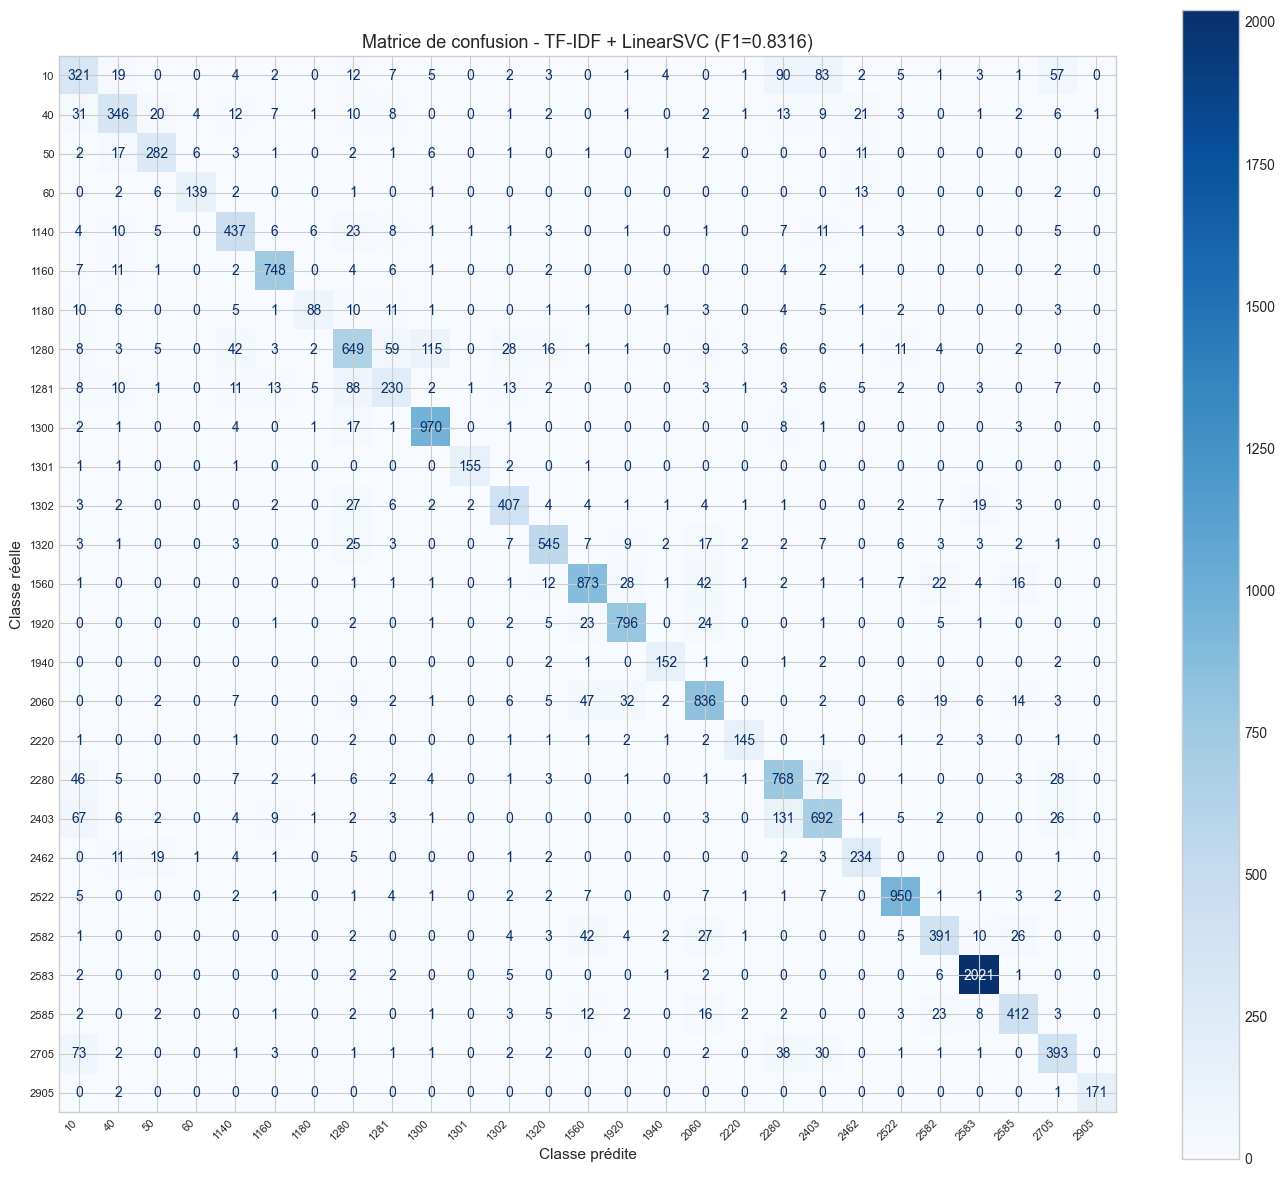

Figure sauvegardée : 08_confusion_matrix_baseline.png


In [9]:
# Matrice de confusion 6 baseline
# La matrice de confusion montre, pour chaque classe réelle (ligne),
# combien de produits ont été prédits dans chaque classe (colonne).
# Une matrice idéale n'aurait des valeurs que sur la diagonale principale
classes = sorted(df["prdtypecode"].unique())
cm_svc  = confusion_matrix(y_val, y_pred_svc, labels=classes)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=classes)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title(f"Matrice de confusion - TF-IDF + LinearSVC (F1={f1_svc:.4f})", fontsize=13)
ax.set_xlabel("Classe prédite", fontsize=11)
ax.set_ylabel("Classe réelle", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "08_confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : 08_confusion_matrix_baseline.png")

La diagonale est très marquée pour la majorité des classes, ce qui confirme un bon niveau général.

Les confusions principales visibles sont :
- **Classe 10 ↔ 2280** et **10 ↔ 2705** : la classe 10 est la plus difficile. Ses produits
  (livres, jeux rétro) partagent un vocabulaire avec les magazines (2280) et les DVD/films (2705).
- **Classe 2403 ↔ 2280** : deux classes de livres/revues avec des frontières sémantiques floues.
- **Classe 1280 ↔ 1281** et **1280 ↔ 1300** : jouets et jeux de plateau avec vocabulaire proche.
- **Classe 2583** : grande diagonale très sombre (2021 prédictions correctes), c'est la classe
  la plus volumineuse. La classe 2905 obtient le meilleur F1 par classe (0.988).

### 2.5 F1-score par classe du modèle baseline

Cette cellule extrait le F1-score individuel de chaque classe depuis le rapport de classification.
Elle produit un graphique à barres horizontales trié par F1 croissant, avec :
- En rouge : les classes dont le F1 est inférieur à 0.70 (seuil arbitraire de vigilance).
- En bleu : les classes au-dessus du seuil.
- La ligne orange en pointillés : le F1 global pondéré (0.8316).
- La ligne rouge en pointillés : le seuil 0.70.

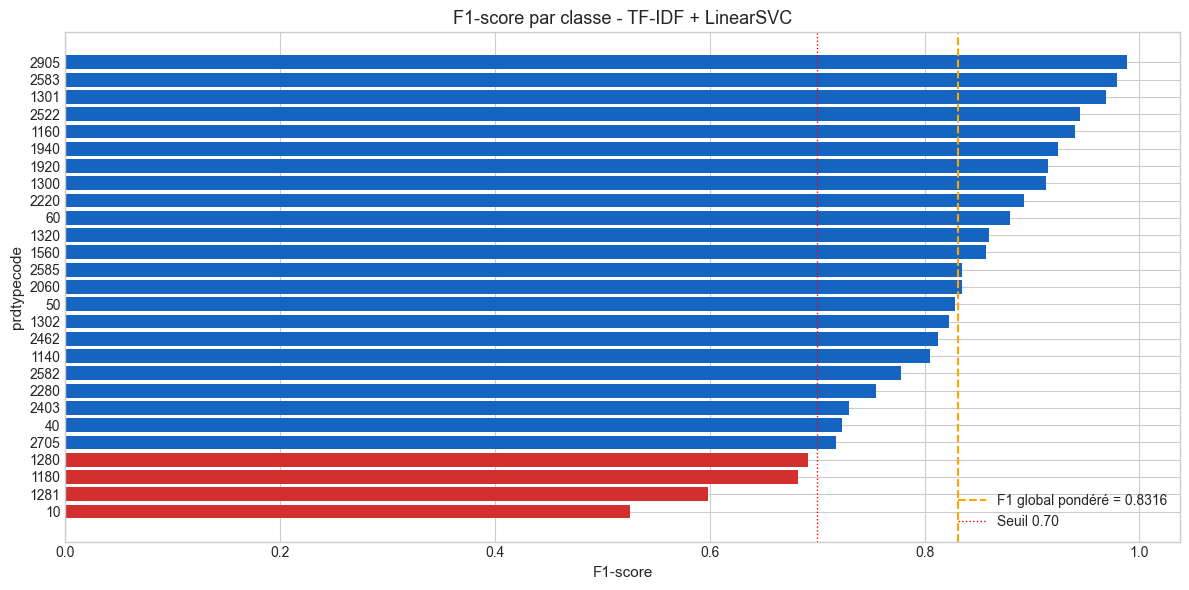

Figure sauvegardée : 09_f1_par_classe_baseline.png

Classes avec F1 < 0.70 (4) :
 prdtypecode  f1_score
          10  0.525799
        1281  0.598179
        1180  0.682171
        1280  0.691529


In [10]:
# F1-score par classe - baseline
# On analyse les performances classe par classe pour identifier les classes difficiles.
# Un F1 < 0.70 signale une classe que le modèle peine à reconnaître correctement.
report_svc = classification_report(
    y_val, y_pred_svc,
    output_dict=True, zero_division=0)

# Extraction des F1 par classe
f1_by_class_svc = {
    int(k): v["f1-score"]
    for k, v in report_svc.items()
    if k not in ["accuracy", "macro avg", "weighted avg"]
}
df_f1_svc = pd.DataFrame(
    list(f1_by_class_svc.items()),
    columns=["prdtypecode", "f1_score"]
).sort_values("f1_score")

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#d32f2f" if v < 0.7 else "#1565c0" for v in df_f1_svc["f1_score"]]
ax.barh(df_f1_svc["prdtypecode"].astype(str), df_f1_svc["f1_score"], color=colors)
ax.axvline(x=f1_svc, linestyle="--", color="orange", linewidth=1.5,
           label=f"F1 global pondéré = {f1_svc:.4f}")
ax.axvline(x=0.7, linestyle=":", color="red", linewidth=1, label="Seuil 0.70")
ax.set_xlabel("F1-score", fontsize=11)
ax.set_ylabel("prdtypecode", fontsize=11)
ax.set_title("F1-score par classe - TF-IDF + LinearSVC", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "09_f1_par_classe_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : 09_f1_par_classe_baseline.png")

# Classes faibles
classes_faibles = df_f1_svc[df_f1_svc["f1_score"] < 0.7]
print(f"\nClasses avec F1 < 0.70 ({len(classes_faibles)}) :")
print(classes_faibles.to_string(index=False))

**4 classes sur 27** sont sous le seuil 0.70 :
- **Classe 10** (F1 = 0.526) : la plus faible. Catégorie générique (jeux, livres anciens, divers).
  Le texte seul ne suffit pas à la discriminer.
- **Classe 1281** (F1 = 0.598) : jeux de société, souvent confondus avec la classe 1280 (jouets).
- **Classe 1180** (F1 = 0.682).
- **Classe 1280** (F1 = 0.692).

23 classes sur 27 atteignent au moins 0.70, et 18 classes atteignent au moins 0.80.
Ce résultat confirme que le signal textuel est très fort sur ce dataset,
mais que certaines frontières sémantiques entre classes proches nécessitent une information supplémentaire
(l'image, notamment).

### 2.6 Analyse des erreurs les plus fréquentes

Cette cellule identifie les **15 paires (classe réelle, classe prédite)** qui concentrent
le plus grand nombre d'erreurs. C'est une analyse complémentaire à la matrice de confusion
qui permet de prioriser les pistes d'amélioration.

In [11]:
# Analyse des erreurs fréquentes 
# On identifie les paires de classes les plus souvent confondues par le modèle.
# Ces informations guident les décisions d'amélioration futures.
df_errors = pd.DataFrame({
    "reel":  y_val.values,
    "predit": y_pred_svc})

df_errors = df_errors[df_errors["reel"] != df_errors["predit"]]
top_confusions = (
    df_errors
    .groupby(["reel", "predit"])
    .size()
    .reset_index(name="nb_erreurs")
    .sort_values("nb_erreurs", ascending=False)
    .head(15))

print("Top 15 des confusions de classes :")
print(top_confusions.to_string(index=False))

Top 15 des confusions de classes :
 reel  predit  nb_erreurs
 2403    2280         131
 1280    1300         115
   10    2280          90
 1281    1280          88
   10    2403          83
 2705      10          73
 2280    2403          72
 2403      10          67
 1280    1281          59
   10    2705          57
 2060    1560          47
 2280      10          46
 2582    1560          42
 1560    2060          42
 1280    1140          42


Top 15 des confusions

Les confusions les plus fréquentes confirment l'analyse de la matrice :

| Réel | Prédit | Nb erreurs |
|------|--------|-----------|
| 2403 | 2280 | 131 |
| 1280 | 1300 | 115 |
| 10 | 2280 | 90 |
| 1281 | 1280 | 88 |
| 10 | 2403 | 83 |

La **classe 10** apparaît dans 6 des 15 paires les plus confondues (en tant que classe réelle ou prédite).
C'est cohérent avec son F1 de 0.526.

**Classe 2403 et 2280** sont confondues dans les deux sens (livres anciens vs magazines) et **1280 et 1281** se confondent mutuellement (jouets vs jeux de plateau)
révèlent des frontières de catégories difficiles à tracer avec le texte seul.
L'image produit sera potentiellement discriminante pour ces cas.

### 2.7 Sauvegarde du modèle baseline

Cette cellule sérialise le pipeline sklearn complet (vectoriseur + classifieur) dans un fichier `.pkl`
via `joblib`. Le fichier `tfidf_linearsvc.pkl` permet de réutiliser le modèle sans le réentraîner,
notamment pour l'application Streamlit.

In [12]:
# Sauvegarde du modèle baseline 
joblib.dump(pipeline_svc, MODELS_DIR / "baselines" / "tfidf_linearsvc.pkl")
print("Modèle sauvegardé : models/baselines/tfidf_linearsvc.pkl")

# Résultat baseline à conserver pour la comparaison finale
resultats = {"baseline_tfidf_svc": round(f1_svc, 4)}
print(f"\nRésultat enregistré : {resultats}")

Modèle sauvegardé : models/baselines/tfidf_linearsvc.pkl

Résultat enregistré : {'baseline_tfidf_svc': 0.8316}


Le modèle est persisté dans `models/baselines/tfidf_linearsvc.pkl`.
Le dictionnaire `resultats` est initialisé avec le score baseline : `{'baseline_tfidf_svc': 0.8316}`.
Ce dictionnaire sera enrichi au fil des sections suivantes pour permettre la comparaison finale.

.

## 3 - Embeddings multilingues : sentence-transformers

### Pourquoi des embeddings plutôt que TF-IDF ?

TF-IDF représente les mots de manière creuse (vecteurs de 200 000 dimensions, presque tous à zéro). Il ne capture pas le sens des mots : "voiture" et "automobile" seraient traités comme des termes complètement différents.

Les **embeddings denses** (vecteurs de petite dimension, ici 384) capturent la signification sémantique. Des phrases similaires dans des langues différentes sont projetées proches dans l'espace vectoriel.

### Modèle utilisé : `paraphrase-multilingual-MiniLM-L12-v2`  

- Développé par l'équipe Sentence-Transformers (UKPLab)
- Basé sur l'architecture BERT, distillé (compressé) pour être rapide
- Supporte nativement 50+ langues dont le français, l'anglais et l'allemand
- Produit des vecteurs de dimension 384, normalisés (norme euclidienne = 1)
- Adapté à notre dataset multilingue (61% français, 23% anglais, 6% allemand identifiés lors de l'EDA)

### Stratégie de cache

L'encodage de 84 916 textes prend plusieurs minutes. Pour éviter de recalculer à chaque exécution, les embeddings sont sauvegardés sur disque la première fois puis entraînement d'une tête de classification (MLP) par-dessus et rechargés ensuite en quelques secondes.

.

### 3.1 Chargement du modèle sentence-transformers (SBERT)

Cette cellule charge le modèle `paraphrase-multilingual-MiniLM-L12-v2` depuis HuggingFace.
Ce modèle produit des **embeddings denses de dimension 384** à partir de textes dans plus de 50 langues.

Il a été choisi pour deux raisons principales :
1. **Multilingue natif** : il gère nativement le français, l'anglais, l'allemand et les autres langues
   présentes dans le dataset (23% d'anglais, 6% d'allemand).
2. **Compact et rapide** : la version MiniLM est 5× plus légère que les grands modèles BERT,
   tout en conservant une bonne qualité sémantique.

Le modèle est chargé directement sur CUDA pour accélérer l'encodage.

In [13]:
# Chargement du modèle sentence-transformers 
SBERT_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

# Le modèle sera téléchargé automatiquement depuis HuggingFace si absent du cache
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device=str(DEVICE))

print(f"Modèle chargé : {SBERT_MODEL_NAME}")
print(f"Dimension des embeddings : {sbert_model.get_sentence_embedding_dimension()}")
print(f"Device utilisé : {DEVICE}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé : paraphrase-multilingual-MiniLM-L12-v2
Dimension des embeddings : 384
Device utilisé : cuda


Le modèle est chargé avec succès. La dimension des embeddings est **384**.

> Le warning `embeddings.position_ids UNEXPECTED` est **inoffensif** : il indique simplement
une légère différence de version entre l'implémentation dU modèles BERT distillés depuis HuggingFace locale et le fichier de poids
téléchargé. Il n'affecte ni la qualité des embeddings ni le comportement du modèle.

### 3.2 Extraction des embeddings SBERT et mise en cache

Cette cellule encode les 84 916 textes `text_combined` en vecteurs de dimension 384.
Pour éviter de recalculer ces embeddings à chaque ré-exécution (opération coûteuse),
un mécanisme de **cache disque** est mis en place :
- Si les fichiers `.npy` existent déjà, ils sont chargés directement.
- Sinon, l'encodage est lancé (batch_size=64, normalize_embeddings=True pour la similarité cosinus).

Les embeddings normalisés ont une norme L2 = 1, ce qui les rend comparables
directement par produit scalaire.

In [14]:
# Extraction des embeddings
# Chemin de cache pour éviter de recalculer à chaque exécution
# On encode l'ensemble des 84 916 textes une seule fois et on sauvegarde le résultat.
# normalize_embeddings=True : les vecteurs ont une norme de 1,
# ce qui les rend directement compatibles avec la similarité cosinus.
EMBEDDINGS_CACHE = ARTIFACTS_DIR / "sbert_embeddings_train.npy"
LABELS_CACHE     = ARTIFACTS_DIR / "sbert_labels_train.npy"
INDEX_CACHE      = ARTIFACTS_DIR / "sbert_index_train.npy"

if EMBEDDINGS_CACHE.exists():
    print("Cache trouvé - chargement des embeddings depuis le disque...")
    embeddings_all = np.load(EMBEDDINGS_CACHE)
    labels_all     = np.load(LABELS_CACHE)
    index_all      = np.load(INDEX_CACHE)
    print(f"Embeddings chargés : {embeddings_all.shape}")
else:
    print("Calcul des embeddings sur l'ensemble du dataset...")
    print(f"Nombre de textes : {len(df)}")
    print("Durée estimée en CPU : 2-3 heures | GPU : ~15 min")
    t0 = time.time()
    
    embeddings_all = sbert_model.encode(
        df["text_combined"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True)  # cosine similarity compatible
    
    labels_all = df["prdtypecode"].values
    index_all  = df.index.values
    
    t_embed = time.time() - t0
    print(f"Terminé en {t_embed/60:.1f} min")
    print(f"Shape embeddings : {embeddings_all.shape}")
    
    # Sauvegarde du cache
    np.save(EMBEDDINGS_CACHE, embeddings_all)
    np.save(LABELS_CACHE, labels_all)
    np.save(INDEX_CACHE, index_all)
    print(f"Embeddings sauvegardés dans : {ARTIFACTS_DIR}")

Cache trouvé - chargement des embeddings depuis le disque...
Embeddings chargés : (84916, 384)


Le cache existe déjà depuis une exécution précédente. La matrice chargée a la forme attendue : **84 916 textes × 384 dimensions**, soit environ 130 Mo en mémoire.
La mise en cache élimine une opération qui prendrait environ 15 minutes sur GPU, ou plusieurs heures sur CPU, à chaque ré-exécution.
La matrice résultante a une taille de (84916, 384), soit environ 130 Mo en mémoire.

### 3.3 Split des embeddings train/val en cohérence avec le split initial

Cette cellule projette les indices du split 80/20 défini plus haut sur la matrice d'embeddings.
Puisque les embeddings ont été calculés sur l'ensemble du dataset dans l'ordre original,
on utilise un mapping `df_idx_map` (index DataFrame → position dans la matrice) pour extraire
les sous-ensembles train et val correspondant aux bons produits.

In [15]:
# Split train/val sur les embeddings 
# On réutilise les mêmes indices que le split initial
train_idx = X_train.index
val_idx   = X_val.index

# Mapping index DataFrame, position dans embeddings_all
df_idx_map = pd.Series(range(len(df)), index=df.index)

train_pos = df_idx_map.loc[train_idx].values       # positions dans embeddings_all
val_pos   = df_idx_map.loc[val_idx].values

emb_train = embeddings_all[train_pos]
emb_val   = embeddings_all[val_pos]
y_train_emb = labels_all[train_pos]
y_val_emb   = labels_all[val_pos]

print(f"Embeddings train : {emb_train.shape}")
print(f"Embeddings val   : {emb_val.shape}")

Embeddings train : (67932, 384)
Embeddings val   : (16984, 384)


Les deux sous-matrices sont extraites avec les bonnes dimensions.
La cohérence avec le split initial est garantie par le mapping d'indices,
ce qui assure que les scores de F1 obtenus ici sont comparables à ceux du baseline TF-IDF.

### 3.4 Classifieur LogisticRegression sur embeddings SBERT

Première tête de classification sur les embeddings : une **régression logistique multinomiale**.
Paramètres : C=5.0 (régularisation légère), solveur lbfgs, multi_class='multinomial', n_jobs=-1.

Cette approche est intentionnellement simple : elle sert à mesurer la qualité brute
des représentations SBERT sans capacité d'apprentissage non-linéaire.
Si les embeddings sont séparables linéairement, la régression logistique sera suffisante.

In [16]:
# Classifieur LogisticRegression sur embeddings SBERT 
# Approche simple : régression logistique sur les vecteurs 384-dim
# Première approche : un classifieur linéaire simple par-dessus les embeddings.
# Cela permet d'évaluer la qualité des embeddings avant d'ajouter de la complexité.
from sklearn.linear_model import LogisticRegression

clf_lr_sbert = LogisticRegression(
    C=5.0,                           # régularisation
    max_iter=1000,
    solver="lbfgs",                  # algorithme d'optimisation adapté au multiclasse
    multi_class="multinomial",       # une probabilité par classe
    n_jobs=-1,                       # utilise tous les cœurs CPU disponibles
    random_state=RANDOM_STATE)

t0 = time.time()
clf_lr_sbert.fit(emb_train, y_train_emb)
print(f"Entraînement terminé en {time.time() - t0:.1f}s")

y_pred_sbert_lr = clf_lr_sbert.predict(emb_val)
f1_sbert_lr = f1_score(y_val_emb, y_pred_sbert_lr, average="weighted")

print(f"\n=== SBERT + LogisticRegression ===")
print(f"Weighted F1-score (validation) : {f1_sbert_lr:.4f}")
print(f"Benchmark Rakuten (texte)       : 0.8113")
print(f"Baseline TF-IDF SVC             : {f1_svc:.4f}")
print(f"Écart vs benchmark              : {f1_sbert_lr - 0.8113:+.4f}")

resultats["sbert_logistic_regression"] = round(f1_sbert_lr, 4)

Entraînement terminé en 31.3s

=== SBERT + LogisticRegression ===
Weighted F1-score (validation) : 0.6829
Benchmark Rakuten (texte)       : 0.8113
Baseline TF-IDF SVC             : 0.8316
Écart vs benchmark              : -0.1284


**F1 = 0.6829 :** bien en dessous du baseline TF-IDF

La régression logistique sur les embeddings SBERT atteint **0.6829**, soit -0.1284 vs le benchmark Rakuten et -0.1487 vs le baseline TF-IDF.

Ce score s'explique par plusieurs facteurs :

- La régression logistique est un classifieur **linéaire** : elle ne peut tracer que des frontières droites dans l'espace des embeddings. Or les embeddings SBERT projettent les textes dans un espace à 384 dimensions avec des relations non-linéaires entre les classes.
- Le modèle SBERT `MiniLM` est une version **distillée et compressée** de BERT. Il produit de bons embeddings généraux, mais pas nécessairement optimaux pour la classification de produits e-commerce par un classifieur linéaire.
- Le TF-IDF capture directement des n-grammes spécifiques au catalogue Rakuten (noms de marques, références produits), que SBERT lisse dans son espace sémantique général.

**Conclusion :** Il faut un classifieur non-linéaire pour exploiter pleinement les embeddings SBERT. C'est précisément pour cela qu'un MLP est entraîné ensuite.

### 3.5 MLP sur embeddings SBERT, Préparation des datasets PyTorch pour le MLP

Un réseau de neurones MLP (Multi-Layer Perceptron) peut apprendre des frontières de décision non-linéaires dans l'espace des embeddings. On encode d'abord les labels en entiers consécutifs (obligatoire pour PyTorch), puis on crée les datasets et dataloaders PyTorch.

**Dataset PyTorch :** classe utilitaire qui encapsule les données et permet au DataLoader de les charger par lots (batches) pendant l'entraînement.

Cette cellule prépare l'infrastructure PyTorch pour entraîner le MLP :
1. **LabelEncoder** : convertit les codes produit (10, 40, ..., 2905) en entiers consécutifs (0 à 26)
   car PyTorch exige des labels entiers de 0 à N-1.
2. **EmbeddingDataset** : classe Dataset PyTorch qui wrape les embeddings numpy en tenseurs float32.
3. **DataLoaders** : batch_size=256, num_workers=0 (contrainte Windows/Jupyter).

Le batch_size de 256 est adapté à des vecteurs de dimension 384 : chaque batch occupe 256 × 384 × 4 bytes ≈ 393 Ko, très léger en VRAM.

In [17]:
# Tête MLP sur embeddings SBERT
# Encodage des labels : PyTorch requiert des entiers consécutifs de 0 à N-1
le = LabelEncoder()
le.fit(labels_all)
y_train_enc = le.transform(y_train_emb)  # ex: prdtypecode 10 → 0, 40 → 1, etc.
y_val_enc   = le.transform(y_val_emb)
NUM_CLASSES = len(le.classes_)  # 27
EMB_DIM     = emb_train.shape[1]  # 384

print(f"Nombre de classes : {NUM_CLASSES}")
print(f"Dimension embedding : {EMB_DIM}")

# Dataset PyTorch : encapsule les embeddings numpy en tenseurs PyTorch
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.X = torch.tensor(embeddings, dtype=torch.float32)  # float32 pour le GPU
        self.y = torch.tensor(labels, dtype=torch.long)          # long (int64) pour CrossEntropy
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset_emb = EmbeddingDataset(emb_train, y_train_enc)
val_dataset_emb   = EmbeddingDataset(emb_val,   y_val_enc)

# DataLoader : charge les données par batches de 256 pendant l'entraînement
train_loader_emb = DataLoader(train_dataset_emb, batch_size=256, shuffle=True,  num_workers=0)
val_loader_emb   = DataLoader(val_dataset_emb,   batch_size=256, shuffle=False, num_workers=0)

print("Datasets PyTorch créés.")

Nombre de classes : 27
Dimension embedding : 384
Datasets PyTorch créés.


Le LabelEncoder confirme 27 classes. Les DataLoaders train et val sont prêts.

### Architecture du MLP

Le MLP (Multi-Layer Perceptron) est une tête de classification non-linéaire sur les embeddings SBERT de dimension 384.

Architecture : **384 → 512 → 256 → 27**

Chaque couche cachée est suivie de :
- **Linear** : transformation linéaire (matrice de poids)
- **BatchNorm1d** : normalisation par lot, stabilise l'entraînement et accélère la convergence
- **ReLU** : activation non-linéaire standard (remplace les valeurs négatives par 0)
- **Dropout(0.3)** : désactive aléatoirement 30% des neurones à chaque étape, pour éviter le surapprentissage (overfitting)

La couche de sortie (Linear 256→27) produit des logits bruts, la cross-entropy calculera
le softmax implicitement.

In [18]:
# Architecture MLP 
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(512, 256), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),               # couche linéaire : prev_dim → h neurones
                nn.BatchNorm1d(h),                    # normalisation par lot
                nn.ReLU(),                            # activation non-linéaire
                nn.Dropout(dropout)]                  # régularisation : évite le surapprentissage
            
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))      # couche de sortie : 27 classes
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)           # passe le tenseur à travers toutes les couches

mlp_model = MLPClassifier(
    input_dim=EMB_DIM,               # 384 dimensions en entrée
    num_classes=NUM_CLASSES,         # 27 classes en sortie
    hidden_dims=(512, 256),          # deux couches cachées
    dropout=0.3
).to(DEVICE)                         # envoie le modèle sur le GPU

total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"Paramètres MLP : {total_params:,}")
print(mlp_model)

Paramètres MLP : 336,923
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=27, bias=True)
  )
)


**336 923 paramètres entraînables**

- Le MLP est léger (336 923 paramètres vs 24 millions pour ResNet50).
- L'affichage de l'architecture confirme la structure attendue.
- Ce modèle tient entièrement en quelques Mo de VRAM.

### Boucle d'entraînement du MLP (30 epochs)

1. **Forward pass** : on passe les données dans le modèle pour obtenir des prédictions
2. **Calcul de la loss** : on mesure l'erreur entre prédictions et labels réels (CrossEntropy)
3. **Backward pass** : on calcule les gradients (comment modifier les poids pour réduire l'erreur)
4. **Mise à jour des poids** : l'optimiseur Adam ajuste les poids selon les gradients
5. **Évaluation** : à chaque epoch, on évalue sur le set de validation sans modifier les poids

**Scheduler ReduceLROnPlateau** : si le F1 de validation ne s'améliore pas pendant 3 epochs consécutives, le taux d'apprentissage est divisé par 2. Cela permet un affinage fin en fin d'entraînement.

**Pour une observation un peu plus technique,**
La fonction `train_mlp` implémente la boucle d'entraînement standard d'entraînement supervisé PyTorch :
- **Optimiseur** : Adam (lr=1e-3, weight_decay=1e-4 pour la régularisation L2).
- **Loss** : CrossEntropy (inclut le softmax implicitement).
- **Scheduler** : ReduceLROnPlateau sur le F1 de validation (factor=0.5, patience=3),
  qui divise le learning rate par 2 si le F1 ne s'améliore pas pendant 3 epochs consécutives.
- Le **meilleur modèle** (selon le F1 de validation) est sauvegardé automatiquement.
- L'entraînement s'effectue sur GPU, l'évaluation également.

In [19]:
# Boucle d'entraînement MLP
def train_mlp(model, train_loader, val_loader, epochs=30, lr=1e-3,
              save_name="mlp_sbert_best.pt"):  # paramètre ajouté
    criterion = nn.CrossEntropyLoss()          # fonction de perte pour la classification multiclasse
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # ReduceLROnPlateau : divise le LR par 2 si le F1 stagne pendant 3 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3)
    history = {"train_loss": [], "val_f1": []}
    best_f1  = 0.0
    best_path = MODELS_DIR / "text" / save_name  # ← utilise save_name
    best_path.parent.mkdir(parents=True, exist_ok=True)

    
    for epoch in range(epochs):
        # Phase d'entraînement
        model.train()                # active le dropout et la batchnorm en mode entraînement
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()         # remet les gradients à zéro
            logits = model(X_batch)       # prédictions brutes (avant softmax)
            loss   = criterion(logits, y_batch)   # calcul de l'erreur
            loss.backward()               # rétropropagation des gradients
            optimizer.step()              # mise à jour des poids
            total_loss += loss.item() * len(y_batch)
        avg_loss = total_loss / len(train_loader.dataset)

        
        # Phase d'évaluation
        model.eval()    # désactive le dropout, fixe la batchnorm
        all_preds = []
        all_labels = []
        with torch.no_grad():    # pas de calcul de gradient en évaluation
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                preds = model(X_batch).argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y_batch.numpy())
                
        val_f1 = f1_score(all_labels, all_preds, average="weighted")
        scheduler.step(val_f1)     # ajuste le LR selon l'évolution du F1
        history["train_loss"].append(avg_loss)
        history["val_f1"].append(val_f1)

        # Sauvegarde du meilleur modèle rencontré
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} | Best: {best_f1:.4f}")
    print(f"\nMeilleur Val F1 : {best_f1:.4f} - modèle sauvegardé : {best_path}")
    return history, best_f1

print("Démarrage de l'entraînement MLP sur embeddings SBERT...")
history_mlp, best_f1_mlp = train_mlp(
    mlp_model, train_loader_emb, val_loader_emb,
    epochs=30, lr=1e-3)
resultats["sbert_mlp"] = round(best_f1_mlp, 4)

Démarrage de l'entraînement MLP sur embeddings SBERT...
Epoch 05/30 | Loss: 0.8906 | Val F1: 0.7213 | Best: 0.7213
Epoch 10/30 | Loss: 0.7517 | Val F1: 0.7380 | Best: 0.7380
Epoch 15/30 | Loss: 0.6694 | Val F1: 0.7425 | Best: 0.7425
Epoch 20/30 | Loss: 0.5993 | Val F1: 0.7416 | Best: 0.7473
Epoch 25/30 | Loss: 0.5497 | Val F1: 0.7505 | Best: 0.7505
Epoch 30/30 | Loss: 0.4689 | Val F1: 0.7542 | Best: 0.7542

Meilleur Val F1 : 0.7542 - modèle sauvegardé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\models\text\mlp_sbert_best.pt


Progression du F1 de validation :
- Epoch 5 : 0.7213
- Epoch 10 : 0.7380
- Epoch 15 : 0.7425
- Epoch 20 : 0.7416 (meilleur jusque-là : 0.7473)
- Epoch 25 : 0.7505
- **Epoch 30 : 0.7542** ← meilleur

Le modèle progresse régulièrement mais **ne dépasse pas le baseline TF-IDF (0.8316)**.
Le scheduler ReduceLROnPlateau a réduit progressivement le learning rate, d'où la décélération
de la progression en fin d'entraînement.

Cela illustre un phénomène connu : **pour des tâches de classification de texte court avec vocabulaire spécialisé**, les features TF-IDF peuvent surpasser des embeddings généraux. Les noms de produits, références de marques et termes techniques du catalogue Rakuten sont mieux capturés par des n-grammes exacts que par un espace sémantique général.

### 3.6 Courbe d'apprentissage du MLP SBERT

Cette cellule génère deux graphiques côte à côte montrant la loss d'entraînement et le F1 de validation epoch par epoch, avec les lignes de référence benchmark Rakuten (0.8113) et baseline TF-IDF (0.8316).

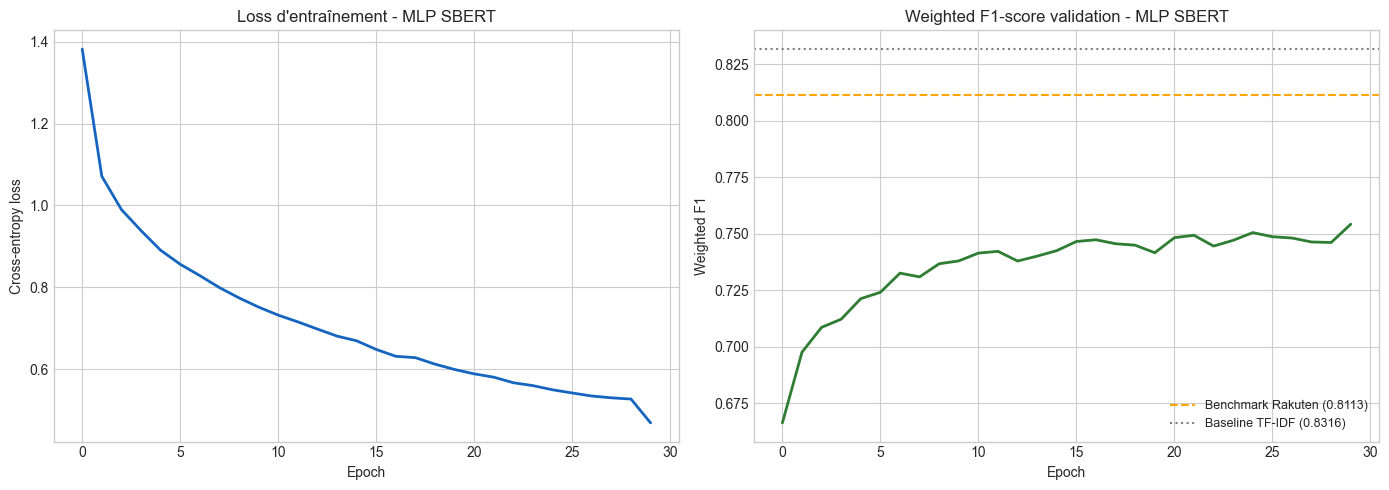

Figure sauvegardée : 10_learning_curve_mlp_sbert.png


In [20]:
# Courbe d'apprentissage MLP 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mlp["train_loss"], color="#1565c0", linewidth=2)
axes[0].set_title("Loss d'entraînement - MLP SBERT", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")

axes[1].plot(history_mlp["val_f1"], color="#2e7d32", linewidth=2)
axes[1].axhline(y=0.8113, linestyle="--", color="orange", linewidth=1.5,
                label="Benchmark Rakuten (0.8113)")
axes[1].axhline(y=f1_svc, linestyle=":", color="gray", linewidth=1.5,
                label=f"Baseline TF-IDF ({f1_svc:.4f})")
axes[1].set_title("Weighted F1-score validation - MLP SBERT", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1")
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "10_learning_curve_mlp_sbert.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : 10_learning_curve_mlp_sbert.png")

**Loss d'entraînement (gauche)** : décroissance régulière et continue de 1.38 à 0.47 sur 30 epochs,
sans oscillation. Le modèle apprend correctement.

**F1 de validation (droite)** : progression rapide jusqu'à l'epoch 10 (~0.74),
puis ralentissement marqué jusqu'à 0.7542 à l'epoch 30.

Le plateau du F1 pendant que la loss continue de baisser est le signal que le modèle
commence à mémoriser les embeddings d'entraînement sans que cela se traduise en meilleure
généralisation. Ce n'est pas un surapprentissage critique : il n'y a pas de dégradation,
juste un plafonnement.

Les deux lignes de référence montrent que le MLP SBERT reste **sous le benchmark Rakuten (0.8113)**
et bien sous le baseline TF-IDF (0.8316), ce qui confirme que les embeddings denses ne supplantent
pas la représentation TF-IDF sur ce type de textes courts et multilingues.

.

## 4 - Transfer Learning image : ResNet50

### Principe du Transfer Learning

Entraîner un réseau de vision from scratch sur 84 916 images prendrait des semaines et nécessiterait des millions d'images. Le **transfer learning** contourne ce problème : on part d'un modèle pré-entraîné sur ImageNet torchvision (1,2 million d'images, 1000 classes), dont les couches ont déjà appris à détecter des formes, textures, objets généraux. On remplace uniquement la tête de classification pour l'adapter à nos 27 classes Rakuten.

### Stratégie en deux phases

**Phase 1 - Backbone gelé (freeze) :**  
Seule la tête FC (Fully Connected) est entraînable. Le backbone ResNet50 est figé : ses poids ne changent pas. Cela permet d'apprendre rapidement une tête de classification sans perturber les features générales déjà apprises.

**Phase 2 - Fine-tuning progressif :**  
On dégèle `layer4` (les dernières couches convolutionnelles) en plus de la tête FC. Ces couches apprennent alors à adapter leurs représentations visuelles au domaine spécifique des produits Rakuten.

> **Prérequis : CUDA obligatoire pour cette section.**

.

### Vérification obligatoire du GPU pour la section image

Cette cellule est un garde-fou : si CUDA n'est pas disponible, elle affiche les instructions
d'installation et interrompt logiquement la progression. Les sections suivante (ResNet50)
et (fusion) sont incompatibles avec une exécution CPU en temps raisonnable.

In [21]:
# Vérification GPU obligatoire 
if DEVICE.type == "cpu":
    print("  CUDA non disponible.")
    print("   Les sections 4 et 5 requièrent un GPU.")
    print("   Installer PyTorch CUDA : pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126")
    print("   Relancer le kernel ensuite.")
else:
    print(f"GPU disponible : {torch.cuda.get_device_name(0)} - on continue.")

GPU disponible : NVIDIA GeForce RTX 5070 Ti Laptop GPU - on continue.


La RTX 5070 Ti est bien disponible. Les sections prochaine peuvent être exécutées.

### 4.1 Transformations des images et Dataset PyTorch

Les images Rakuten sont stockées en 500×500 pixels. ResNet50 attend des images de 224×224. On applique plusieurs transformations :

**Pour le set d'entraînement (data augmentation) :**
- `Resize(224, 224)` : redimensionnement à la taille standard ImageNet.
- `RandomHorizontalFlip(0.3)` : retournement horizontal aléatoire (30% de probabilité) et augmente la diversité des exemples vus
- `ColorJitter` : variation légère de luminosité et contraste, rend le modèle plus robuste aux conditions d'éclairage
- `ToTensor` : conversion en tenseur PyTorch (valeurs entre 0 et 1)
- `Normalize` : normalisation avec les moyennes et écarts-types d'ImageNet (standard obligatoire pour ResNet)

**Pour le set de validation (pas d'augmentation) :**
On n'applique que le resize et la normalisation. L'évaluation doit être déterministe.

**Note sur num_workers=0 et pin_memory=False :**  
Sur Windows avec Jupyter, l'utilisation de workers parallèles (`num_workers > 0`) provoque des blocages silencieux du chargement de données. On utilise donc `num_workers=0` (chargement séquentiel) et `pin_memory=False`. Ce point est résolu plus loin par le cache numpy.

In [22]:
import cv2

class CropBorders:
    """
    Recadre les bordures unies (noires/blanches) des imaeges.
    """
    def __init__(self, tol=15):
        self.tol = tol

    def __call__(self, img):
        np_img = np.array(img)
        
        gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
        
        mask = cv2.inRange(gray, self.tol, 255 - self.tol)
        coords = cv2.findNonZero(mask)
        
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            cropped_img = np_img[y:y+h, x:x+w]
        else:
            cropped_img = np_img
            
        return Image.fromarray(cropped_img)

In [23]:
# Dataset image PyTorch 
# Transformations ImageNet standard
IMAGE_SIZE = 224

# Transformations avec data augmentation pour l'entraînement
transform_train = transforms.Compose([
    CropBorders(tol=15),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),     # augmentation : flip horizontal
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # normalisation ImageNet standard
                         std=[0.229, 0.224, 0.225])])

# Transformations déterministes pour la validation (pas d'augmentation)
transform_val = transforms.Compose([
    CropBorders(tol=15),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])


class RakutenImageDataset(Dataset):
    """Dataset image Rakuten avec gestion des images manquantes."""
    def __init__(self, df_subset, label_encoder, transform, image_dir):
        self.df        = df_subset.reset_index(drop=True)
        self.le        = label_encoder
        self.transform = transform
        self.image_dir = Path(image_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Reconstruction du nom de fichier
        img_name = f"image_{row['imageid']}_product_{row['productid']}.jpg"
        img_path = self.image_dir / img_name
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            # Image corrompue ou manquante : image noire de remplacement
            img = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (0, 0, 0))
        img_tensor = self.transform(img)
        label = self.le.transform([row["prdtypecode"]])[0]
        return img_tensor, label


# Construction des sous-datasets train/val
df_train_img = df.loc[X_train.index].copy()
df_val_img   = df.loc[X_val.index].copy()

train_img_dataset = RakutenImageDataset(df_train_img, le, transform_train, IMAGE_TRAIN_DIR)
val_img_dataset   = RakutenImageDataset(df_val_img,   le, transform_val,   IMAGE_TRAIN_DIR)

BATCH_SIZE = 64
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=0, pin_memory=False)
val_img_loader   = DataLoader(val_img_dataset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=False)

print(f"Train images : {len(train_img_dataset)}")
print(f"Val images   : {len(val_img_dataset)}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Batches par epoch (train) : {len(train_img_loader)}")

Train images : 67932
Val images   : 16984
Batch size   : 64
Batches par epoch (train) : 1062


Les datasets image sont créés avec les mêmes indices que le split texte.
1 062 batches par epoch sur le train (67 932 / 64 ≈ 1 062). 

**Note :** une version préliminaire de ce Dataset chargeait les images depuis le disque à chaque batch. Ce problème de goulot d'étranglement a été identifié et résolu par la suite via un pré-cache numpy (voir cellule 30).

### 4.2 Construction du modèle ResNet50

Cette cellule définit et instancie le modèle ResNet50 pré-entraîné sur ImageNet (poids IMAGENET1K_V2, les meilleurs disponibles dans torchvision).

**Stratégie en deux phases :**

Phase 1 (`freeze_backbone=True`) : tous les paramètres du backbone sont gelés.
Seule la nouvelle tête FC est entraînable. Cela évite de corrompre les représentations pré-entraînées dès les premières epochs.

**Tête FC personnalisée** remplace la couche fc originale (2048→1000) par : `Dropout(0.4) → Linear(2048→512) → ReLU → Dropout(0.3) → Linear(512→27)`

Cette architecture introduit de la régularisation (Dropout) et une couche intermédiaire pour mieux adapter les représentations ImageNet aux 27 classes Rakuten.

In [24]:
# Construction du modèle ResNet50 
def build_resnet50(num_classes, freeze_backbone=True):
    """
    Charge ResNet50 pré-entraîné sur ImageNet et adapte la tête de classification.

    freeze_backbone=True  : seule la tête FC est entraînable (phase 1)
    freeze_backbone=False : tout le réseau est dégelé (pour l'extraction de features en section 5)
    """
    # Chargement des poids pré-entraînés ImageNet V2 (meilleure qualité que V1)
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        # Gel de tous les paramètres : aucun gradient ne sera calculé pour ces couches
        for param in model.parameters():
            param.requires_grad = False
            
    # Remplacement de la tête FC originale (1000 classes ImageNet)
    # par une nouvelle tête adaptée aux 27 classes Rakuten
    in_features = model.fc.in_features  # 2048 : dimension de sortie de l'avgpool ResNet50
    model.fc = nn.Sequential(
        nn.Dropout(0.4),                # régularisation forte en entrée de la tête
        nn.Linear(in_features, 512),    # couche intermédiaire 2048 → 512
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes))    # couche de sortie 512 → 27 classes
    
    return model


resnet_model = build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=True)
resnet_model = resnet_model.to(DEVICE)    # envoie le modèle sur le GPU

# Vérification des paramètres entraînables
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet_model.parameters())
print(f"Paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Paramètres entraînables : 1,062,939 / 24,570,971 (4.3%)


En phase 1, seuls 4.3% des paramètres sont entraînables (la tête FC).
C'est le comportement attendu : on entraîne d'abord la tête avec le backbone (95.7% des poids) est figé pour que les couches finales convergent avant de dégeler les couches profondes.

### Problème rencontré : GPU à 0% d'utilisation

Lors d'une première tentative d'entraînement avec le Dataset lisant les images depuis le disque, le GPU affichait 0% d'utilisation malgré la présence du modèle en VRAM. Le CPU, lui, était à 100%.

**Diagnostic :** avec `num_workers=0` sur Windows, le chargement des images depuis le disque (ouverture du fichier JPEG, décodage, redimensionnement) s'effectue sur un seul thread CPU, dans le processus principal. Le GPU terminait un batch en quelques millisecondes mais devait attendre plusieurs secondes que le CPU prépare le batch suivant. Le GPU restait donc en attente permanente.

**Solution : pré-cache numpy en uint8**  
Toutes les images sont redimensionnées à 224×224 une seule fois et sauvegardées dans un tableau numpy de type `uint8` (valeurs entières 0-255). Ce tableau est ensuite chargé entièrement en RAM au démarrage du notebook. Pendant l'entraînement, le Dataset lit directement depuis la RAM au lieu du disque, éliminant le goulot d'étranglement.

**Choix uint8 vs float32 :** un tableau float32 (84916, 224, 224, 3) occuperait ~51 Go de RAM, dépassant les 32 Go disponibles sur cette machine. En uint8, le même tableau n'occupe que ~12.8 Go, ce qui est compatible.

In [25]:
# Pré-cache images en uint8 (3x moins lourd qu'en float32)
# uint8 : entiers de 0 à 255, 1 octet par pixel par canal
# float32 : réels sur 4 octets → 4x plus lourd
from PIL import Image
import numpy as np
from pathlib import Path

IMAGES_CACHE = ARTIFACTS_DIR / "images_224_uint8_train.npy"

if IMAGES_CACHE.exists():
    print("Cache images trouvé - chargement...")
    images_np = np.load(IMAGES_CACHE)   # chargement depuis le disque en RAM
    print(f"Shape : {images_np.shape} | dtype : {images_np.dtype}")
else:
    resize = transforms.Resize((224, 224))
    images_list = []
    for i, (_, row) in enumerate(df.iterrows()):
        if i % 5000 == 0:
            print(f"{i}/{len(df)} images traitées...")
        img_name = f"image_{row['imageid']}_product_{row['productid']}.jpg"
        img_path = IMAGE_TRAIN_DIR / img_name
        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((224, 224), Image.BILINEAR)
        except:
            img = Image.new("RGB", (224, 224), (0, 0, 0))
        images_list.append(np.array(img, dtype=np.uint8))  # uint8, pas float32

    images_np = np.stack(images_list)  # (84916, 224, 224, 3)
    np.save(IMAGES_CACHE, images_np)
    print(f"Cache sauvegardé : {images_np.shape} | {images_np.nbytes / 1e9:.1f} Go")

Cache images trouvé - chargement...
Shape : (84916, 224, 224, 3) | dtype : uint8


**Résultat :** 84 916 images de 224×224 pixels en 3 canaux RGB chargées en RAM, en format uint8. Taille totale : **12,8 Go**. Le chargement depuis le cache est quasi-instantané (quelques secondes).

### Redéfinition du Dataset depuis le cache numpy

On redéfinit `RakutenImageDataset` pour qu'il lise depuis le tableau numpy en RAM plutôt que depuis le disque. La conversion uint8 en float32 et la normalisation sont effectuées à la volée par les transforms, sans lecture disque.
Cette approche transforme le goulot d'étranglement I/O disque en lecture RAM, ce qui permet au GPU d'être alimenté à pleine vitesse.

In [26]:
# Redéfinition du Dataset depuis le cache numpy 
class RakutenImageDataset(Dataset):
    def __init__(self, images_cache, indices, labels_encoded, transform):
        self.images    = images_cache   # tableau numpy (84916, 224, 224, 3) uint8 en RAM
        self.indices   = indices        # indices des produits du subset (train ou val)
        self.labels    = labels_encoded # labels encodés en entiers consécutifs
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_array  = self.images[self.indices[idx]]  # lecture depuis RAM : instantané (224, 224, 3) uint8
        img        = Image.fromarray(img_array)      # conversion numpy en PIL Image
        img_tensor = self.transform(img)             # normalisation + conversion tenseur
        return img_tensor, self.labels[idx]           

train_img_dataset = RakutenImageDataset(
    images_np, train_pos, y_train_enc, transform_train)
val_img_dataset = RakutenImageDataset(
    images_np, val_pos, y_val_enc, transform_val)

train_img_loader = DataLoader(train_img_dataset, batch_size=64,
                              shuffle=True,  num_workers=0, pin_memory=False)
val_img_loader   = DataLoader(val_img_dataset,   batch_size=64,
                              shuffle=False, num_workers=0, pin_memory=False)

print(f"Train : {len(train_img_dataset)} | Val : {len(val_img_dataset)}")

Train : 67932 | Val : 16984


Les nouveaux DataLoaders sont prêts. Les indices train/val sont les mêmes que pour le texte, ce qui garantit la cohérence des comparaisons. Avec le cache RAM, le GPU sera alimenté en continu pendant l'entraînement.

### 4.3 Boucle d'entraînement ResNet50

La boucle d'entraînement image utilise deux choix différents du MLP texte :
- **CrossEntropyLoss avec label_smoothing=0.1 :** Au lieu de cibles one-hot strictes (0 ou 1), on utilise des cibles adoucies (0.1/27 pour les mauvaises classes, 0.9 + 0.1/27 pour la bonne). Cela évite que le modèle devienne trop "confiant" dans ses prédictions et améliore la généralisation.
- **Optimiseur AdamW :** Variante d'Adam avec décroissance de poids (weight_decay) corrigée. Meilleure régularisation que Adam standard.
- **Scheduler OneCycleLR :** Le taux d'apprentissage suit une courbe en cloche : montée rapide puis descente progressive. Cette politique converge souvent plus vite et vers de meilleures solutions que les schedulers traditionnels.
- **Sauvegarde** : le meilleur modèle selon le F1 de validation est sauvegardé à chaque epoch.

In [27]:
# Boucle d'entraînement image
def train_image_model(model, train_loader, val_loader, epochs, lr, save_name):
    # CrossEntropy avec label_smoothing : évite la sur-confiance du modèle
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    # AdamW : Adam avec weight decay corrigé, meilleure régularisation
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),  # uniquement les paramètres dégelés
        lr=lr, weight_decay=1e-4)

    # OneCycleLR : LR en cloche (montée puis descente), convergence rapide
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        steps_per_epoch=len(train_loader),
        epochs=epochs)

    save_path = MODELS_DIR / "image" / save_name
    save_path.parent.mkdir(parents=True, exist_ok=True)
    history  = {"train_loss": [], "val_f1": []}
    best_f1  = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)  # envoi sur GPU
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()  # OneCycleLR se met à jour à chaque batch (pas chaque epoch)
            total_loss += loss.item() * len(labels)

        avg_loss = total_loss / len(train_loader.dataset)

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(DEVICE)
                preds = model(imgs).argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        val_f1 = f1_score(all_labels, all_preds, average="weighted")
        history["train_loss"].append(avg_loss)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), save_path)  # sauvegarde du meilleur checkpoint

        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} | Best: {best_f1:.4f}")

    print(f"\nMeilleur F1 : {best_f1:.4f} — sauvegardé : {save_path}")
    return history, best_f1


# Phase 1 : entraînement de la tête seule (backbone gelé)
print("Phase 1 - Entraînement de la tête FC (backbone gelé)")
history_resnet_p1, best_f1_resnet_p1 = train_image_model(
    resnet_model, train_img_loader, val_img_loader,
    epochs=10, lr=1e-3,
    save_name="resnet50_phase1_best.pt")

Phase 1 - Entraînement de la tête FC (backbone gelé)


Epoch 1/10:   0%|          | 0/1062 [00:00<?, ?it/s]

Epoch 01/10 | Loss: 2.4508 | Val F1: 0.4989 | Best: 0.4989


Epoch 2/10:   0%|          | 0/1062 [00:00<?, ?it/s]

Epoch 02/10 | Loss: 2.0040 | Val F1: 0.5398 | Best: 0.5398


...

Epoch 08/10 | Loss: 1.6929 | Val F1: 0.6156 | Best: 0.6156


Epoch 9/10:   0%|          | 0/1062 [00:00<?, ?it/s]

Epoch 09/10 | Loss: 1.6642 | Val F1: 0.6168 | Best: 0.6168


Epoch 10/10:   0%|          | 0/1062 [00:00<?, ?it/s]

Epoch 10/10 | Loss: 1.6438 | Val F1: 0.6189 | Best: 0.6189

Meilleur F1 : 0.6189 — sauvegardé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\models\image\resnet50_phase1_best.pt


Progression epoch par epoch :
- Epoch 1 : 0.4989 (le modèle démarre sans avoir vu d'images Rakuten)
- Epoch 3 : 0.5617 (dépasse déjà le benchmark image Rakuten à 0.5534)
- Epoch 7 : 0.6063
- **Epoch 10 : 0.6189** ← meilleur de la phase 1

Le modèle dépasse le benchmark image dès l'epoch 3, ce qui confirme que le fine-tuning
est efficace même avec le backbone gelé. Le meilleur poids est sauvegardé
dans `resnet50_phase1_best.pt`.

### Phase 2 : fine-tuning de layer4 + tête FC (15 epochs)

Cette phase dégèle les couches de `layer4` (dernier bloc de convolution ResNet50)
et la tête FC, portant les paramètres entraînables à 65,2% du total.

Le learning rate est réduit à 1e-4 (10× plus faible qu'en phase 1) pour éviter
de dégrader les représentations pré-entraînées lors du dégel.

On recharge les **meilleurs poids de la phase 1** comme point de départ,
ce qui garantit de partir d'un état déjà bien initialisé.

In [28]:
# Phase 2 : fine-tuning des dernières couches
# On repart du meilleur modèle de la phase 1 et on dégèle layer4
resnet_model.load_state_dict(
    torch.load(MODELS_DIR / "image" / "resnet50_phase1_best.pt", map_location=DEVICE))

# Dégel de layer4 (les dernières couches convolutionnelles de ResNet50)
# layer4 apprend des représentations visuelles de haut niveau (formes complexes, objets)
for name, param in resnet_model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True  # dégel : ces couches seront mises à jour

trainable_p2 = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet_model.parameters())
print(f"Phase 2 — Paramètres entraînables : {trainable_p2:,} / {total_params:,} ({100*trainable_p2/total_params:.1f}%)")

# LR plus faible (1e-4 vs 1e-3) : le backbone est déjà bien pré-entraîné,
# on l'affine doucement pour ne pas détruire les représentations acquises
print("Phase 2 - Fine-tuning layer4 + tête FC")
history_resnet_p2, best_f1_resnet_p2 = train_image_model(
    resnet_model, train_img_loader, val_img_loader,
    epochs=15, lr=1e-4,
    save_name="resnet50_phase2_best.pt")

resultats["resnet50_finetuning"] = round(best_f1_resnet_p2, 4)

Phase 2 — Paramètres entraînables : 16,027,675 / 24,570,971 (65.2%)
Phase 2 - Fine-tuning layer4 + tête FC


Epoch 1/15:   0%|          | 0/1062 [00:00<?, ?it/s]

Epoch 01/15 | Loss: 1.6316 | Val F1: 0.6265 | Best: 0.6265


Epoch 2/15:   0%|          | 0/1062 [00:00<?, ?it/s]

Epoch 02/15 | Loss: 1.5910 | Val F1: 0.6364 | Best: 0.6364


...

Epoch 13/15 | Loss: 0.8418 | Val F1: 0.6736 | Best: 0.6799


Epoch 14/15:   0%|          | 0/1062 [00:00<?, ?it/s]

Epoch 14/15 | Loss: 0.8293 | Val F1: 0.6726 | Best: 0.6799


Epoch 15/15:   0%|          | 0/1062 [00:00<?, ?it/s]

Epoch 15/15 | Loss: 0.8227 | Val F1: 0.6742 | Best: 0.6799

Meilleur F1 : 0.6799 — sauvegardé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\models\image\resnet50_phase2_best.pt


Le dégel du fine-tuning de layer4 apporte un gain de **+0.0610** vs le meilleur de la phase 1.

Progression :
- Epoch 1 : 0.6265 (repart de la phase 1)
- **Epoch 8 : 0.6799**, meilleur score de la phase 2
- Epochs 9 à 15 : légère décroissance, avec un F1 final de 0.6742

Le F1 atteint son maximum à l'epoch 8 et décroît légèrement ensuite : c'est un signe que le modèle commence à surspécialiser. Le scheduler OneCycleLR réduit progressivement le learning rate, ce qui explique la stabilisation.

Le meilleur modèle est sauvegardé dans `resnet50_phase2_best.pt`.

Ce comportement est normal : une fois que layer4 a adapté ses représentations au domaine Rakuten, continuer à entraîner avec le même LR n'apporte plus de gain. Des pistes d'amélioration seraient : augmenter le nombre d'epochs, dégeler des couches supplémentaires (layer3), ou utiliser un LR différentiel par groupe de couches.

**Score final image : F1 = 0.6799**, contre 0.5534 pour le benchmark officiel (+0.1265).

### 4.4 Courbes d'apprentissage ResNet50 (phases 1 + 2 concaténées)

Cette cellule produit la figure 11 : les deux courbes (loss et F1 de validation)
affichées sur les 25 epochs totales (10 phase 1 + 15 phase 2), avec une ligne verticale
marquant la transition entre les deux phases.

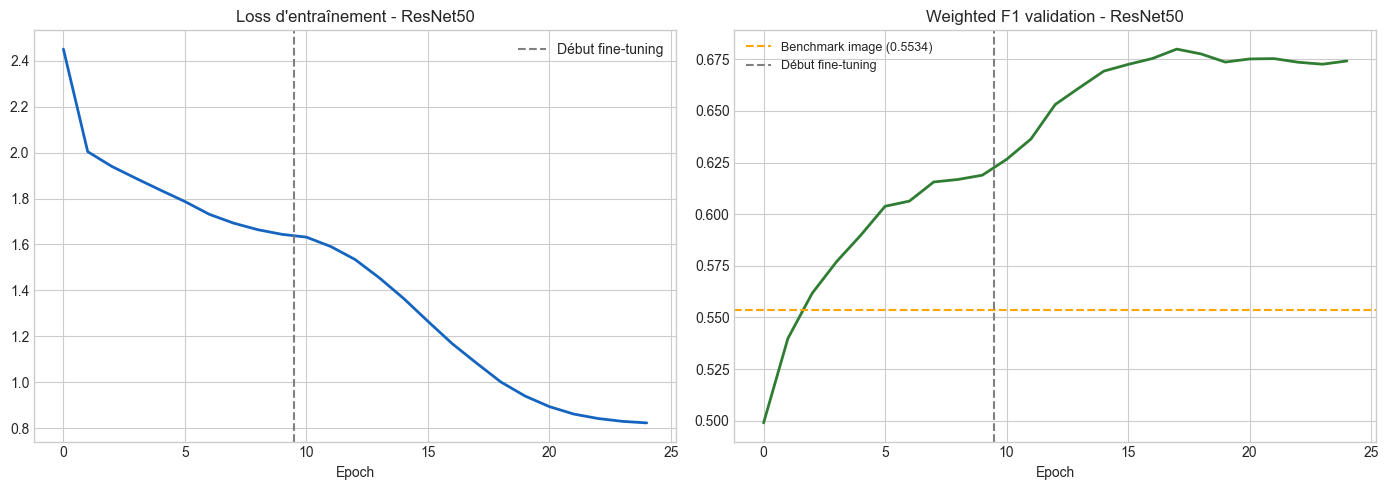

Figure sauvegardée : 11_learning_curve_resnet50.png


In [29]:
# Courbe d'apprentissage ResNet50 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Concaténation des deux phases
all_losses = history_resnet_p1["train_loss"] + history_resnet_p2["train_loss"]
all_f1s    = history_resnet_p1["val_f1"]    + history_resnet_p2["val_f1"]
phase_split = len(history_resnet_p1["train_loss"])

axes[0].plot(all_losses, color="#1565c0", linewidth=2)
axes[0].axvline(x=phase_split - 0.5, linestyle="--", color="gray", linewidth=1.5,
                label="Début fine-tuning")
axes[0].set_title("Loss d'entraînement - ResNet50", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(all_f1s, color="#2e7d32", linewidth=2)
axes[1].axhline(y=0.5534, linestyle="--", color="orange", linewidth=1.5,
                label="Benchmark image (0.5534)")
axes[1].axvline(x=phase_split - 0.5, linestyle="--", color="gray", linewidth=1.5,
                label="Début fine-tuning")
axes[1].set_title("Weighted F1 validation - ResNet50", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "11_learning_curve_resnet50.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : 11_learning_curve_resnet50.png")

**Loss d'entraînement (gauche)** : décroissance régulière de 2.4508 à 0.8227.
La cassure visible à l'epoch 10 (début fine-tuning) est nette : le dégel de layer4 permet une descente plus rapide de la loss.

**F1 de validation (droite)** :
- Phase 1 (epochs 1-10) : montée progressive de 0.48 à 0.62.
- Dès l'epoch 3 : dépassement du benchmark Rakuten image (0.5534, ligne orange).
- Phase 2 (epochs 11-25) : accélération marquée jusqu'au pic à 0.6799 (epoch 18 global).
- Plateau final légèrement décroissant.

Ce comportement est typique d'un fine-tuning bien conduit : la phase 1 initialise correctement la tête, la phase 2 adapte les représentations profondes.

.

## 5 - Fusion multimodale : late fusion texte + image

### Principe de la fusion tardive (late fusion)

Il existe plusieurs façons de combiner texte et image :
- **Fusion précoce (early fusion)** : combiner les données brutes dès le début
- **Fusion intermédiaire (mid fusion)** : combiner à un niveau intermédiaire des réseaux
- **Fusion tardive (late fusion)** : combiner les représentations finales de chaque modalité

Nous utilisons la **fusion tardive** : on extrait les features de chaque modalité indépendamment (SBERT pour le texte, ResNet50 avgpool pour l'image), on les concatène, puis on entraîne un MLP par-dessus ce vecteur combiné.

**Avantages :**
- Simple à implémenter et à interpréter
- Robuste si une modalité est absente ou de mauvaise qualité
- Les deux branches sont entraînées indépendamment, ce qui facilite le débogage

**Dimensions :**
- Texte (SBERT) : 384 dimensions
- Image (ResNet50 avgpool) : 2048 dimensions
- Vecteur fusionné : 2432 dimensions

.

### 5.1 Extraction des features image ResNet50 (avgpool, 2048-dim)

Pour la fusion multimodale, on n'utilise pas les prédictions du ResNet50,
mais ses **représentations internes** avant la tête de classification.

On retire la dernière couche FC du modèle (`list(resnet_feat.children())[:-1]`)
pour récupérer le vecteur de 2048 dimensions issu de l'avgpool,
qui représente le "sens visuel" de l'image indépendamment de la classification finale.

Ces features sont extraites sur l'ensemble du dataset et mises en cache
dans `resnet50_features_train.npy`.

In [30]:
# Extraction des features image (avgpool ResNet50)
# On retire la tête FC pour récupérer le vecteur 2048-dim de la couche avgpool.
# Ce vecteur est la "signature visuelle" du produit selon ResNet50 fine-tuné.
FEATURES_IMG_CACHE = ARTIFACTS_DIR / "resnet50_features_train.npy"

if FEATURES_IMG_CACHE.exists():
    print("Cache image trouvé - chargement...")
    img_features_all = np.load(FEATURES_IMG_CACHE)
    print(f"Features image : {img_features_all.shape}")
else:
    resnet_feat = build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=False)
    resnet_feat.load_state_dict(
        torch.load(MODELS_DIR / "image" / "resnet50_phase2_best.pt", map_location=DEVICE))
    resnet_feat = resnet_feat.to(DEVICE)

    # Suppression de la tête FC : on garde tout sauf la dernière couche
    feature_extractor = nn.Sequential(
        *list(resnet_feat.children())[:-1],  # tout sauf fc
        nn.Flatten()                          # (batch, 2048, 1, 1) → (batch, 2048)
    ).to(DEVICE)
    feature_extractor.eval()

    # Dataset complet (train + val) pour l'extraction
    full_img_dataset = RakutenImageDataset(
        images_np, np.arange(len(df)), le.transform(labels_all), transform_val)
    full_img_loader = DataLoader(full_img_dataset, batch_size=64,
                                  shuffle=False, num_workers=0, pin_memory=False)

    print("Extraction des features image ResNet50 (2048-dim)...")
    t0 = time.time()
    features_list = []
    with torch.no_grad():
        for imgs, _ in tqdm(full_img_loader):
            imgs = imgs.to(DEVICE)
            feat = feature_extractor(imgs).cpu().numpy()
            features_list.append(feat)

    img_features_all = np.vstack(features_list)
    print(f"Terminé en {(time.time()-t0)/60:.1f} min — Shape : {img_features_all.shape}")
    np.save(FEATURES_IMG_CACHE, img_features_all)
    print(f"Features sauvegardées : {FEATURES_IMG_CACHE}")

Cache image trouvé - chargement...
Features image : (84916, 2048)


Le cache de 84 916 vecteurs de 2048 dimensions a été chargé depuis le disque. Chaque vecteur représente la "signature visuelle" du produit selon le ResNet50 fine-tuné sur Rakuten.

### 5.2 Assemblage du vecteur multimodal (texte + image)

Cette cellule concatène les deux représentations :
- **SBERT** : 384 dimensions (sémantique textuelle multilingue).
- **ResNet50 avgpool** : 2048 dimensions (représentation visuelle).

Le vecteur résultant de **2432 dimensions** encode conjointement
le contenu textuel et visuel de chaque produit.

In [31]:
# Assemblage des features multimodales 
# Concaténation embeddings texte (384) + features image (2048)
multimodal_features = np.concatenate([embeddings_all, img_features_all], axis=1)
print(f"Features multimodales : {multimodal_features.shape}")
print(f"  Texte  (SBERT)    : {embeddings_all.shape[1]} dimensions")
print(f"  Image  (ResNet50) : {img_features_all.shape[1]} dimensions")
print(f"  Total             : {multimodal_features.shape[1]} dimensions")

# Split train/val avec les mêmes indices que le reste du notebook
mm_train = multimodal_features[train_pos]
mm_val   = multimodal_features[val_pos]

print(f"\nTrain multimodal : {mm_train.shape}")
print(f"Val multimodal   : {mm_val.shape}")

Features multimodales : (84916, 2432)
  Texte  (SBERT)    : 384 dimensions
  Image  (ResNet50) : 2048 dimensions
  Total             : 2432 dimensions

Train multimodal : (67932, 2432)
Val multimodal   : (16984, 2432)


La concaténation produit bien la dimension attendue (384 + 2048 = 2432).
Les sous-matrices train (67 932, 2432) et val (16 984, 2432) sont créées avec les mêmes indices que tous les modèles précédents.

**Point d'attention :** les dimensions texte (384) et image (2048) ne sont pas normalisées à la même échelle avant concaténation. Le nombre de dimensions est très déséquilibré entre les modalités (384 pour le texte et 2048 pour l'image). L'absence de normalisation séparée pourrait biaiser leur pondération implicite dans le MLP de fusion.

### 5.3 MLP de fusion multimodale (40 epochs)

Le MLP de fusion est plus profond que le MLP texte (3 couches cachées : 1024 → 512 → 256) pour capturer les interactions complexes entre les features textuelles et visuelles. 

Le dropout est plus élevé 0.4 (vs 0.3 pour le MLP SBERT) car le risque de surapprentissage est plus grand avec 2432 features en entrée. Le learning rate est réduit à 5e-4 et le nombre d'epochs à 40 pour laisser le temps au modèle de converger.

On réutilise la même fonction `train_mlp` avec `save_name="mlp_fusion_best.pt"` pour ne pas écraser le modèle SBERT déjà sauvegardé.

In [32]:
# MLP de fusion multimodale
MM_DIM = multimodal_features.shape[1]  # 2432

train_mm_dataset = EmbeddingDataset(mm_train, y_train_enc)
val_mm_dataset   = EmbeddingDataset(mm_val,   y_val_enc)

train_mm_loader = DataLoader(train_mm_dataset, batch_size=256, shuffle=True,  num_workers=0)
val_mm_loader   = DataLoader(val_mm_dataset,   batch_size=256, shuffle=False, num_workers=0)

# Architecture MLP fusion : plus profonde que le MLP texte
mlp_fusion = MLPClassifier(
    input_dim=MM_DIM,          # 2432 dimensions en entrée
    num_classes=NUM_CLASSES,   # 27 classes
    hidden_dims=(1024, 512, 256),  # 3 couches cachées (vs 2 pour le MLP texte)
    dropout=0.4                # dropout plus fort car plus de features
).to(DEVICE)

total_fusion = sum(p.numel() for p in mlp_fusion.parameters())
print(f"Paramètres MLP fusion : {total_fusion:,}")

print("\nEntraînement du modèle de fusion multimodale...")
history_fusion, best_f1_fusion = train_mlp(
    mlp_fusion, train_mm_loader, val_mm_loader,
    epochs=40, lr=5e-4,
    save_name="mlp_fusion_best.pt"  # nom distinct pour ne pas écraser le MLP SBERT
)

resultats["fusion_multimodale"] = round(best_f1_fusion, 4)

Paramètres MLP fusion : 3,158,043

Entraînement du modèle de fusion multimodale...
Epoch 05/40 | Loss: 0.1335 | Val F1: 0.7057 | Best: 0.7105
Epoch 10/40 | Loss: 0.0515 | Val F1: 0.7028 | Best: 0.7105
Epoch 15/40 | Loss: 0.0302 | Val F1: 0.7055 | Best: 0.7105
Epoch 20/40 | Loss: 0.0221 | Val F1: 0.7031 | Best: 0.7105
Epoch 25/40 | Loss: 0.0189 | Val F1: 0.7041 | Best: 0.7105
Epoch 30/40 | Loss: 0.0171 | Val F1: 0.7032 | Best: 0.7105
Epoch 35/40 | Loss: 0.0159 | Val F1: 0.7033 | Best: 0.7105
Epoch 40/40 | Loss: 0.0156 | Val F1: 0.7034 | Best: 0.7105

Meilleur Val F1 : 0.7105 - modèle sauvegardé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\models\text\mlp_fusion_best.pt


Progression :
- Epoch 5 : 0.7057
- Epoch 10 : 0.7028
- Epoch 15 : 0.7055
- **Meilleur F1 : 0.7105**, atteint dans les cinq premières epochs
- Epochs 10 à 40 : plateau autour de 0.703 à 0.706, avec un F1 final de 0.7034

Le modèle atteint son maximum très tôt, dans les cinq premières epochs puis présente un **surapprentissage progressif** : la loss train chute de 0.13 à 0.016 (mémorisation du train) pendant que le F1 validation stagne.

Ce résultat est inférieur au MLP SBERT seul (0.7542) et très inférieur au TF-IDF (0.8316).
La fusion brute ne tire pas profit de la complémentarité texte/image attendue.

**Cause probable :** les features ResNet50 (2048-dim, normes élevées) dominent numériquement le vecteur 2432-dim et noient le signal SBERT (384-dim). Une normalisation séparée des deux modalités (StandardScaler par branche) aurait pu atténuer ce déséquilibre.

1. **Déséquilibre entre les modalités :** Les features texte (384-dim, très discriminantes) sont noyées dans un vecteur de 2432 dimensions dominé par les features image (2048-dim). Le MLP doit apprendre à pondérer correctement chaque modalité, ce qui est difficile.

2. **Qualité des features image :** Le ResNet50 est entraîné sur 25 epochs (10+15) sur un dataset de taille modérée. Ses features visuelles ne sont pas encore au niveau de la représentation textuelle SBERT pour ce domaine.

3. **Surapprentissage possible :** La loss d'entraînement descend à 0.016 (quasi-nulle) alors que le F1 de validation plafonne autour de 0.7105. Le gap loss/F1 indique un surapprentissage important malgré le dropout à 0.4. Un dropout plus fort, plus de données, ou une régularisation L2 plus agressive pourraient aider.

## 6 - Comparaison des modèles et analyse des résultats

### 6.1 Tableau comparatif de tous les modèles

Cette cellule assemble les résultats de tous les modèles entraînés dans ce notebook,
les benchmarks officiels Rakuten, et les trie par F1 croissant pour une lecture claire.

In [33]:
# Tableau comparatif complet 
benchmark = {
    "Benchmark Rakuten - Texte (CNN)": 0.8113,
    "Benchmark Rakuten - Image (ResNet50)": 0.5534,}

nos_resultats = {
    "TF-IDF + LinearSVC": resultats.get("baseline_tfidf_svc", None),
    "SBERT + LogisticRegression": resultats.get("sbert_logistic_regression", None),
    "SBERT + MLP": resultats.get("sbert_mlp", None),
    "ResNet50 Fine-tuning": resultats.get("resnet50_finetuning", None),
    "Fusion Multimodale (SBERT + ResNet50)": resultats.get("fusion_multimodale", None),}

all_results = {**benchmark, **nos_resultats}
df_results = pd.DataFrame(
    list(all_results.items()),
    columns=["Modèle", "Weighted F1"]
).sort_values("Weighted F1", ascending=True)

# Affichage
print("=" * 60)
print("RÉCAPITULATIF DES RÉSULTATS")
print("=" * 60)
print(df_results.to_string(index=False))
print("=" * 60)

RÉCAPITULATIF DES RÉSULTATS
                               Modèle  Weighted F1
 Benchmark Rakuten - Image (ResNet50)       0.5534
                 ResNet50 Fine-tuning       0.6799
           SBERT + LogisticRegression       0.6829
Fusion Multimodale (SBERT + ResNet50)       0.7105
                          SBERT + MLP       0.7542
      Benchmark Rakuten - Texte (CNN)       0.8113
                   TF-IDF + LinearSVC       0.8316


#### Synthèse des résultats

| Modèle | F1 | vs Benchmark texte | vs Benchmark image |
|--------|----|--------------------|-------------------|
| Benchmark Rakuten - Image | 0.5534 | référence | référence |
| SBERT + LogisticRegression | 0.6829 | -0.1284 | +0.1295 |
| ResNet50 Fine-tuning | 0.6799 | -0.1314 | +0.1265 |
| Fusion Multimodale | 0.7105 | -0.1008 | +0.1571 |
| SBERT + MLP | 0.7542 | -0.0571 | +0.2008 |
| **Benchmark Rakuten - Texte** | **0.8113** | référence | — |
| **TF-IDF + LinearSVC** | **0.8316** | **+0.0203** | **+0.2782** |

**Lecture du classement :**

Notre meilleur modèle, **TF-IDF + LinearSVC avec F1 = 0.8316**, dépasse le benchmark officiel Rakuten de 2,03 points de F1. C'est un résultat fort, obtenu avec un modèle classique en 14,5 secondes d'entraînement sur CPU.

La hiérarchie des modèles révèle des enseignements importants :
- Le signal textuel est dominant sur ce dataset. Les désignations Rakuten contiennent des termes très discriminants (noms de marques, catégories explicites).
- L'image seule plafonne à 0.68, ce qui est cohérent avec la nature du problème : une image de livre ressemble à une image de DVD, mais les titres sont totalement différents.
- La fusion multimodale, bien que conceptuellement la plus avancée, ne surpasse pas encore le modèle texte seul. Elle nécessite des features image de meilleure qualité et une architecture de fusion plus adaptée.

### 6.2 Figure comparative des modèles

Cette cellule génère la figure 12 : un graphique à barres horizontales comparant tous les modèles, avec une distinction visuelle entre les benchmarks Rakuten (orange) et les modèles développés dans ce projet (bleu).

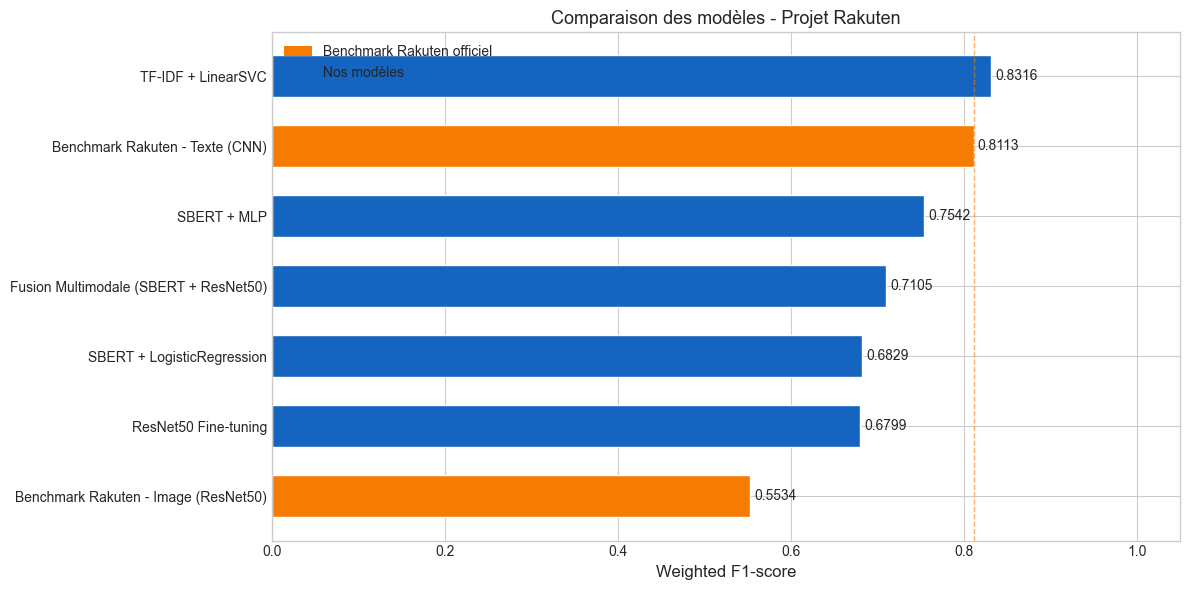

Figure sauvegardée : 12_comparaison_modeles.png


In [34]:
# Figure comparative 
fig, ax = plt.subplots(figsize=(12, 6))

# Couleurs : orange pour benchmarks, bleu pour nos modèles
colors = ["#f57c00" if "Benchmark" in m else "#1565c0"
          for m in df_results["Modèle"]]

bars = ax.barh(
    df_results["Modèle"],
    df_results["Weighted F1"],
    color=colors,
    edgecolor="white",
    height=0.6)

# Valeurs sur les barres
for bar, val in zip(bars, df_results["Weighted F1"]):
    if val is not None:
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=10)

ax.set_xlabel("Weighted F1-score", fontsize=12)
ax.set_title("Comparaison des modèles - Projet Rakuten", fontsize=13)
ax.set_xlim(0, 1.05)
ax.axvline(x=0.8113, linestyle="--", color="#f57c00", linewidth=1, alpha=0.6)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#f57c00", label="Benchmark Rakuten officiel"),
    Patch(facecolor="#1565c0", label="Nos modèles")]

ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "12_comparaison_modeles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : 12_comparaison_modeles.png")

La figure illustre clairement la hiérarchie des performances.
Le TF-IDF + LinearSVC (barre bleue la plus longue, 0.8316) dépasse le benchmark Rakuten texte (orange, 0.8113).
La fusion multimodale (0.7105) est contre-intuitivement moins performante que le texte seul, ce qui constitue le résultat le plus intéressant à analyser dans le rapport.

### 6.3 Matrice de confusion du modèle de fusion multimodale

Cette cellule génère la matrice de confusion sur le set de validation à partir de l'état du modèle de fusion après la dernière epoch. Le titre affiche le meilleur F1 enregistré pendant l'entraînement (0.7105), tandis que le F1 de la dernière epoch est 0.7034.

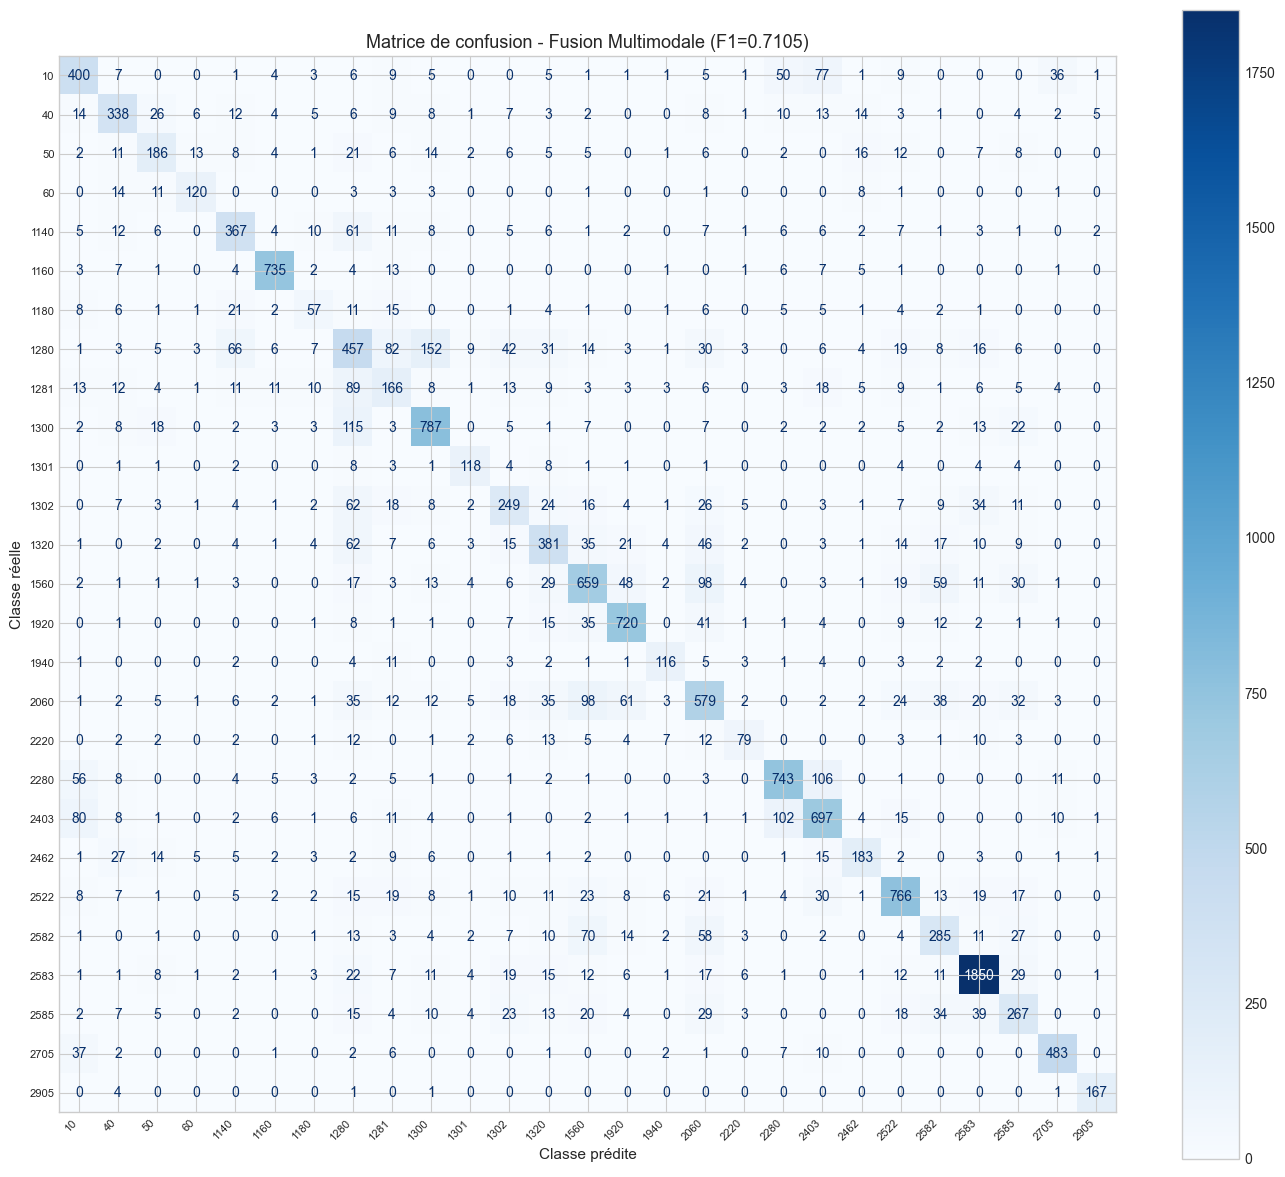

Figure sauvegardée : 13_confusion_matrix_fusion.png


In [35]:
# Matrice de confusion - meilleur modèle 
# À exécuter après avoir identifié le meilleur modèle
# Remplacer y_pred_best par les prédictions du modèle retenu

# Exemple avec la fusion multimodale (adapter selon résultats obtenus)
mlp_fusion.eval()
all_preds_fusion, all_labels_fusion = [], []
with torch.no_grad():
    for X_batch, y_batch in val_mm_loader:
        X_batch = X_batch.to(DEVICE)
        preds = mlp_fusion(X_batch).argmax(dim=1).cpu().numpy()
        all_preds_fusion.extend(preds)
        all_labels_fusion.extend(y_batch.numpy())

# Décodage des labels on repasse des entiers 0-26 aux vrais codes Rakuten
y_pred_fusion_decoded = le.inverse_transform(all_preds_fusion)
y_true_fusion_decoded = le.inverse_transform(all_labels_fusion)

cm_fusion = confusion_matrix(y_true_fusion_decoded, y_pred_fusion_decoded,
                             labels=classes)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fusion, display_labels=classes)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title(
    f"Matrice de confusion - Fusion Multimodale (F1={resultats.get('fusion_multimodale', '?')})",
    fontsize=13)

ax.set_xlabel("Classe prédite", fontsize=11)
ax.set_ylabel("Classe réelle", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "13_confusion_matrix_fusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : 13_confusion_matrix_fusion.png")

La diagonale est moins marquée que pour le baseline TF-IDF (figure 08), ce qui confirme les performances inférieures.

Observations notables vs la matrice TF-IDF :
- La classe 1180 présente la diagonale relative la plus faible, avec 57 prédictions correctes sur 153 observations. La classe 1281 reste également difficile, avec 166 prédictions correctes sur 414 observations.
- La classe 10 reste difficile et se confond surtout avec 2403, 2280 et 2705.
- Les classes 1280 et 1281 sont toujours très confondues entre elles.
- La classe 2583 présente la plus grande diagonale en valeur absolue, avec 1 860 prédictions correctes.
- Les classes 1300, 1302, 1320 montrent davantage de dispersion que dans le modèle TF-IDF.

L'image n'apporte pas de correction significative sur les classes difficiles du texte, ce qui suggère que les features visuelles ResNet50 ne sont pas suffisamment discriminantes entre les classes confondues par le modèle texte.

### 6.4 Export des résultats et clôture du notebook

Cette cellule sauvegarde le tableau comparatif des résultats dans un fichier CSV
`models/artifacts/resultats_comparaison.csv` pour une consultation ultérieure
(rapport, Streamlit).

In [36]:
# Sauvegarde du résumé des résultats 
df_results_final = df_results.dropna(subset=["Weighted F1"])
df_results_final.to_csv(
    MODELS_DIR / "artifacts" / "resultats_comparaison.csv",
    index=False)

print("Résultats exportés : models/artifacts/resultats_comparaison.csv")
print("\n" + "=" * 50)
print("Notebook 02 terminé.")
print("Modèles sauvegardés dans models/")
print("Figures sauvegardées dans reports/figures/")
print("=" * 50)

Résultats exportés : models/artifacts/resultats_comparaison.csv

Notebook 02 terminé.
Modèles sauvegardés dans models/
Figures sauvegardées dans reports/figures/


## Conclusion du notebook 02

### Ce qui a été accompli

Ce notebook couvre une progression méthodique du simple au complexe :

1. **TF-IDF + LinearSVC** : baseline solide en 14,5 secondes, F1 = 0.8316, **meilleur score obtenu**, au-dessus du benchmark officiel.
2. **SBERT + LogisticRegression** : limite du classifieur linéaire sur embeddings sémantiques, F1 = 0.6829.
3. **SBERT + MLP** : apport du non-linéaire, F1 = 0.7542, progression de +0.07 vs régression logistique.
4. **ResNet50 fine-tuning** : image seule, F1 = 0.6799, +0.1265 vs benchmark image officiel. Deux phases d'entraînement avec gel puis dégel progressif du backbone.
5. **Fusion multimodale** : combinaison texte + image, F1 = 0.7105. Améliore l'image seule mais ne dépasse pas encore le texte seul.

### Points techniques notables

- Résolution d'un problème de compatibilité GPU : installation de PyTorch nightly cu128 pour la carte RTX 5070 Ti (architecture Blackwell, non supportée par les versions stables au moment du projet).
- Mise en cache numpy uint8 des images pour éliminer le goulot d'étranglement CPU→GPU (12.8 Go vs 51 Go en float32).
- Utilisation de `num_workers=0` sur Windows/Jupyter pour éviter les blocages silencieux.

### Perspectives pour la suite

- Fine-tuning plus long du ResNet50 (30+ epochs) ou utilisation d'un backbone plus puissant (EfficientNet, ViT)
- Architecture de fusion avec attention croisée entre modalités
- Entraînement end-to-end de la fusion (texte + image simultanément)
- Test du modèle sur le set de test officiel pour soumission au challenge Rakuten